In [5]:
# ============================================
# CELL 1: IMPORTS AND BASE ORCHESTRATOR
# ============================================

import numpy as np
import matplotlib.pyplot as plt
import time
import random
from typing import List, Dict, Tuple, Any, Optional

# Import CL-QAOA solver
try:
    from clustering_solver import ImprovedHierarchicalClusteringSolver
    QAOA_AVAILABLE = True
except ImportError:
    QAOA_AVAILABLE = False

# Import Classical TSP solver
try:
    from classical_solver import ClassicalTSP
    CLASSICAL_AVAILABLE = True
except ImportError:
    CLASSICAL_AVAILABLE = False


class TSPOrchestrator:
    """Main orchestrator for TSP solving with constraint handling."""
    
    def __init__(self):
        self.constraints = {}
        self.results = {}
    
    def set_constraints(self, node_categories=None, road_constraints=None, 
                       time_constraints=None, penalty_scale=1.0):
        """
        Set constraints for TSP problem.
        """
        self.constraints = {
            'node_categories': node_categories,
            'road_constraints': road_constraints,
            'time_constraints': time_constraints,
            'penalty_scale': penalty_scale
        }
    
    def compute_distance_matrix(self, coordinates):
        """Compute Euclidean distance matrix."""
        n = len(coordinates)
        dist_matrix = np.sqrt(((coordinates[:, np.newaxis] - coordinates[np.newaxis, :])**2).sum(axis=2))
        np.fill_diagonal(dist_matrix, 0)
        return dist_matrix
    
    def validate_tour(self, tour, n_cities):
        """Validate if tour is a valid TSP tour."""
        if not tour or len(tour) != n_cities:
            return False
        if len(set(tour)) != n_cities:
            return False
        if min(tour) < 0 or max(tour) >= n_cities:
            return False
        return True
    
    def get_results(self):
        """Get all stored results."""
        return self.results
    
    def clear_results(self):
        """Clear stored results."""
        self.results = {}
    
    @staticmethod
    def compute_tour_cost(tour: List[int], distance_matrix: np.ndarray) -> float:
        """Compute total cost of a tour."""
        if len(tour) <= 1:
            return 0.0
        
        cost = 0.0
        n = len(tour)
        for i in range(n-1):
            cost += distance_matrix[tour[i], tour[i+1]]
        cost += distance_matrix[tour[-1], tour[0]]  # Return to start
        return cost

# Helper function that can be used by all classes
def compute_distance_matrix(coordinates):
    """Compute Euclidean distance matrix (standalone function)."""
    n = len(coordinates)
    dist_matrix = np.sqrt(((coordinates[:, np.newaxis] - coordinates[np.newaxis, :])**2).sum(axis=2))
    np.fill_diagonal(dist_matrix, 0)
    return dist_matrix

>>> classical_optimizer loaded from: C:\Users\Tooba Bibi\Desktop\Conversion of programs\hackathon\hackathon project\quantum_tsp_projectupdate\classical_optimizer.py
✓ All QAOA components loaded successfully


In [ ]:
#helper ftn

In [7]:
# ============================================
# CELL 2: CLUSTER ORCHESTRATOR (CL-QAOA)
# ============================================

class ClusterOrchestrator(TSPOrchestrator):
    """Orchestrator for CL-QAOA solver."""
    
    def solve(self, coordinates, max_cluster_size=3, qaoa_depth=1, use_qaoa=True):
        """
        Solve TSP using CL-QAOA approach with constraint handling.
        
        Args:
            coordinates: Array of (x,y) coordinates
            max_cluster_size: Maximum cities per cluster
            qaoa_depth: QAOA circuit depth
            use_qaoa: Whether to use QAOA or classical fallback
            
        Returns:
            (tour, cost, stats)
        """
        if not QAOA_AVAILABLE:
            raise ImportError("CL-QAOA solver not available")
        
        # Initialize solver WITH constraints
        solver = ImprovedHierarchicalClusteringSolver(
            max_cluster_size=max_cluster_size,
            qaoa_depth=qaoa_depth,
            use_qaoa=use_qaoa,
            # Pass constraints from orchestrator to solver
            node_categories=self.constraints.get('node_categories'),
            road_constraints=self.constraints.get('road_constraints'),
            time_constraints=self.constraints.get('time_constraints'),
            penalty_scale=self.constraints.get('penalty_scale', 1.0)
        )
        
        # Solve with constraints
        tour, cost = solver.solve_full_problem(
            coordinates, 
            constraints=self.constraints  # Pass constraints to solving method
        )
        
        stats = solver.stats
        
        self.results['cl_qaoa'] = {
            'tour': tour,
            'cost': cost,
            'stats': stats,
            'method': 'CL-QAOA',
            'constraints_used': bool(self.constraints)  # Track if constraints were used
        }
        
        return tour, cost, stats
    
    def get_cluster_stats(self):
        """Get CL-QAOA specific statistics."""
        if 'cl_qaoa' in self.results:
            return self.results['cl_qaoa']['stats']
        return {}

In [ ]:
#classica solver

In [9]:
# ============================================
# CELL 3: CLASSICAL SOLVER ORCHESTRATOR (INCLUDES ACO)
# ============================================

class ClassicalOrchestrator(TSPOrchestrator):
    """Orchestrator for classical TSP solvers including Ant Colony Optimization."""
    
    def __init__(self):
        """Initialize with ACO parameter defaults."""
        super().__init__()
        self.aco_parameters = {
            'n_ants': 5,
            'n_iterations': 100,
            'alpha': 1.0,
            'beta': 2.0,
            'rho': 0.5,
            'q0': 0.9,
            'tau0': 1.0,
            'use_local_search': True,
            'use_constraint_awareness': True
        }
    
    def set_aco_parameters(self, **params):
        """Set parameters for Ant Colony Optimization."""
        self.aco_parameters.update(params)
    
    def solve(self, coordinates, method='constraint_aware_sa', **kwargs):
        """
        Solve TSP using classical methods with constraint handling.
        
        Args:
            coordinates: Array of (x,y) coordinates
            method: 'greedy', 'constraint_aware_greedy', 'simulated_annealing', 
                   'constraint_aware_sa', 'ant_colony', or 'brute_force'
            **kwargs: Additional solver parameters
            
        Returns:
            (tour, cost, stats)
        """
        if not CLASSICAL_AVAILABLE:
            raise ImportError("Classical TSP solver not available")
        
        n = len(coordinates)
        distance_matrix = compute_distance_matrix(coordinates)
        
        solver = ClassicalTSP(
            n_cities=n,
            distance_matrix=distance_matrix,
            node_categories=self.constraints.get('node_categories'),
            road_constraints=self.constraints.get('road_constraints'),
            time_constraints=self.constraints.get('time_constraints'),
            penalty_scale=self.constraints.get('penalty_scale', 1.0)
        )
        
        # Method dispatch
        if method == 'greedy':
            tour, cost, stats = solver.greedy_search(
                start_city=kwargs.get('start_city', 0)
            )
            
        elif method == 'constraint_aware_greedy':
            tour, cost, stats = solver.constraint_aware_greedy(
                start_city=kwargs.get('start_city', 0)
            )
            
        elif method == 'simulated_annealing':
            tour, cost, stats = solver.simulated_annealing(
                max_iterations=kwargs.get('max_iterations', 10),
                cooling_rate=kwargs.get('cooling_rate', 0.995)
            )
            
        elif method == 'constraint_aware_sa':
            tour, cost, stats = solver.constraint_aware_simulated_annealing(
                max_iterations=kwargs.get('max_iterations', 10),
                cooling_rate=kwargs.get('cooling_rate', 0.995),
                use_constraint_aware_moves=kwargs.get('use_constraint_aware_moves', True)
            )
            
        elif method == 'ant_colony':
            # Merge ACO parameters
            aco_params = self.aco_parameters.copy()
            aco_params.update({k: v for k, v in kwargs.items() 
                              if k in self.aco_parameters or k == 'use_constraint_awareness'})
            
            tour, cost, stats = solver.constraint_aware_ant_colony(**aco_params)
            
        elif method == 'brute_force' and n <= 8:
            tour, cost, stats = solver.brute_force()
            
        else:
            # Default fallback
            if n <= 8:
                tour, cost, stats = solver.brute_force()
            else:
                tour, cost, stats = solver.constraint_aware_simulated_annealing()
        
        self.results[f'classical_{method}'] = {
            'tour': tour,
            'cost': cost,
            'stats': stats,
            'method': f'classical_{method}',
            'actual_distance': solver.compute_actual_distance(tour),
            'qubo_cost': cost
        }
        
        return tour, cost, stats
    
    # ========== ACO-SPECIFIC METHODS ==========
    
    def solve_with_aco(self, coordinates, **kwargs):
        """Convenience method for ACO."""
        return self.solve(coordinates, method='ant_colony', **kwargs)
    
    def run_aco_experiment(self, coordinates, parameter_name, parameter_values):
        """Run ACO with different parameter values."""
        results = {}
        
        print(f"\nACO Parameter Experiment: {parameter_name}")
        print("-" * 40)
        
        for value in parameter_values:
            print(f"\n{parameter_name} = {value}")
            
            params = {parameter_name: value}
            tour, cost, stats = self.solve_with_aco(coordinates, **params)
            
            results[value] = {
                'cost': cost,
                'tour': tour,
                'stats': stats
            }
            
            print(f"  Cost: {cost:.2f}")
            print(f"  Runtime: {stats.get('runtime', 0):.2f}s")
        
        return results
    
    def plot_aco_convergence(self, coordinates, figsize=(10, 6)):
        """Plot ACO convergence over iterations."""
        _, _, stats = self.solve_with_aco(coordinates)
        
        if 'iteration_best_costs' in stats:
            fig, ax = plt.subplots(figsize=figsize)
            iteration_costs = stats['iteration_best_costs']
            
            ax.plot(iteration_costs, 'b-', linewidth=2, label='Best Cost per Iteration')
            ax.axhline(y=min(iteration_costs), color='r', linestyle='--', 
                      label=f'Best: {min(iteration_costs):.2f}')
            
            ax.set_xlabel('Iteration')
            ax.set_ylabel('QUBO Cost')
            ax.set_title('Ant Colony Optimization Convergence')
            ax.legend()
            ax.grid(True, alpha=0.3)
            
            self.results['aco_convergence_figure'] = fig
            return fig
        
        print("No iteration data available")
        return None
    
    # ========== COMPARISON METHODS ==========
    
    def get_all_methods(self, coordinates, methods=None, compare=False):
        """
        Run all available classical methods.
        
        Args:
            coordinates: Array of (x,y) coordinates
            methods: List of methods to run (default: all available)
            compare: If True, run comprehensive comparison
            
        Returns:
            Dictionary of results
        """
        if compare:
            return self.compare_methods(coordinates)
        
        if methods is None:
            n = len(coordinates)
            methods = ['constraint_aware_greedy', 'constraint_aware_sa', 'ant_colony']
            if n <= 8:
                methods.append('brute_force')
        
        for method in methods:
            try:
                print(f"\nRunning {method}...")
                start_time = time.time()
                tour, cost, stats = self.solve(coordinates, method=method)
                runtime = time.time() - start_time
                
                print(f"  Cost: {cost:.2f}")
                print(f"  Runtime: {runtime:.2f}s")
                print(f"  Tour: {tour[:5]}{'...' if len(tour) > 5 else ''}")
                
            except Exception as e:
                print(f"Error with method {method}: {e}")
        
        return self.results
    
    def compare_methods(self, coordinates, n_runs=3):
        """Run comprehensive comparison of all classical methods."""
        if not CLASSICAL_AVAILABLE:
            raise ImportError("Classical TSP solver not available")
        
        n = len(coordinates)
        distance_matrix = compute_distance_matrix(coordinates)
        
        solver = ClassicalTSP(
            n_cities=n,
            distance_matrix=distance_matrix,
            node_categories=self.constraints.get('node_categories'),
            road_constraints=self.constraints.get('road_constraints'),
            time_constraints=self.constraints.get('time_constraints'),
            penalty_scale=self.constraints.get('penalty_scale', 1.0)
        )
        
        print("\n" + "="*60)
        print("CLASSICAL METHODS COMPARISON")
        print("="*60)
        
        comparison_results = solver.compare_methods(n_runs=n_runs)
        self.results['comparison'] = comparison_results
        
        return comparison_results
    
    def plot_comparison(self, coordinates, figsize=(12, 8)):
        """Plot comparison of classical methods."""
        if 'comparison' not in self.results:
            self.compare_methods(coordinates)
        
        comparison = self.results['comparison']
        
        fig, axes = plt.subplots(1, 2, figsize=figsize)
        
        # Plot 1: Average costs
        methods = ['naive_greedy', 'constraint_aware_greedy', 
                  'constraint_aware_simulated_annealing', 'constraint_aware_ant_colony']
        method_labels = ['Naive Greedy', 'Constraint Greedy', 'Constraint SA', 'Constraint ACO']
        
        avg_costs = []
        best_costs = []
        
        for method in methods:
            if method in comparison:
                avg_costs.append(comparison[method]['avg_cost'])
                best_costs.append(comparison[method]['best_cost'])
        
        x = np.arange(len(method_labels))
        width = 0.35
        
        axes[0].bar(x - width/2, avg_costs, width, label='Average Cost', color='skyblue')
        axes[0].bar(x + width/2, best_costs, width, label='Best Cost', color='lightcoral')
        axes[0].set_xlabel('Method')
        axes[0].set_ylabel('QUBO Cost')
        axes[0].set_title('Method Comparison (Lower is Better)')
        axes[0].set_xticks(x)
        axes[0].set_xticklabels(method_labels, rotation=45, ha='right')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)
        
        # Plot 2: Improvement percentages
        if 'naive_greedy' in comparison:
            base_cost = comparison['naive_greedy']['avg_cost']
            improvements = []
            
            for method in ['constraint_aware_greedy', 'constraint_aware_simulated_annealing', 
                          'constraint_aware_ant_colony']:
                if method in comparison:
                    improvement = ((base_cost - comparison[method]['avg_cost']) / base_cost) * 100
                    improvements.append(improvement)
            
            axes[1].bar(['Greedy', 'SA', 'ACO'], improvements, color=['green', 'orange', 'purple'])
            axes[1].set_xlabel('Constraint-Aware Method')
            axes[1].set_ylabel('Improvement Over Naive Greedy (%)')
            axes[1].set_title('Constraint-Aware Methods Improvement')
            axes[1].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
            axes[1].grid(True, alpha=0.3)
            
            for i, v in enumerate(improvements):
                axes[1].text(i, v + (1 if v >= 0 else -3), f'{v:.1f}%', 
                           ha='center', va='bottom' if v >= 0 else 'top')
        
        plt.tight_layout()
        self.results['comparison_figure'] = fig
        return fig
    
    def get_best_solution(self):
        """Get the best solution from all stored results."""
        if not self.results:
            return None
        
        best_method = None
        best_cost = float('inf')
        best_tour = None
        best_stats = None
        
        for method_name, result in self.results.items():
            if 'cost' in result and result['cost'] < best_cost:
                best_cost = result['cost']
                best_tour = result['tour']
                best_stats = result['stats']
                best_method = method_name
        
        return best_method, best_tour, best_cost, best_stats

In [11]:
def compute_approximation_ratios(tour, distance_matrix, optimal_cost=None, worst_cost=None):
    """Compute AR_exp and AR_min from paper equations 28-29"""
    actual_cost = compute_tour_cost(tour, distance_matrix)
    
    if optimal_cost is None:  # For large problems, use ACO as reference
        # Run ACO to get reference cost
        return normalized_ratio(actual_cost, reference_cost)
    
    # For small problems with known optimal
    AR_min = (actual_cost - worst_cost) / (optimal_cost - worst_cost)
    return AR_min

def compute_comparison_metrics(results_dict, reference_method="Ant Colony"):
    """Compute normalized metrics like paper eq 31"""
    reference_cost = results_dict[reference_method]["cost"]
    
    metrics = {}
    for method, data in results_dict.items():
        if method != reference_method:
            metrics[method] = data["cost"] / reference_cost  # eq 31
    return metrics

In [ ]:
#classical solver

In [13]:
# ============================================
# CELL 1: DATA LOADING AND PREPARATION
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.gridspec import GridSpec
import time
import json
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Load the Islamabad TSP dataset
print("Loading Islamabad TSP dataset...")
df = pd.read_csv('islamabad_tsp_150_realistic_locations.csv')
print(f"Dataset loaded: {len(df)} locations")
print(f"\nLocation types distribution:")
print(df['type'].value_counts())

# Prepare coordinates
coordinates = np.column_stack([df['longitude'].values, df['latitude'].values])
location_names = df['name'].values
location_types = df['type'].values

print(f"\nCoordinates shape: {coordinates.shape}")
print(f"X range: {coordinates[:, 0].min():.4f} to {coordinates[:, 0].max():.4f}")
print(f"Y range: {coordinates[:, 1].min():.4f} to {coordinates[:, 1].max():.4f}")

# Save processed data for later use
np.save('islamabad_coordinates.npy', coordinates)
np.save('islamabad_location_names.npy', location_names)
np.save('islamabad_location_types.npy', location_types)

print("\n✅ Data saved to numpy files for reuse.")

Loading Islamabad TSP dataset...
Dataset loaded: 150 locations

Location types distribution:
sector         58
petrol_pump    29
landmark       21
parking        16
airport        10
hospital        8
hotel           3
mall            3
university      2
Name: type, dtype: int64

Coordinates shape: (150, 2)
X range: 72.8231 to 73.1383
Y range: 33.5467 to 33.7471

✅ Data saved to numpy files for reuse.


✅ Constraints defined and saved to 'tsp_constraints.json'

Node categories distribution:
  normal: 63 nodes
  fuel: 29 nodes
  must_visit: 21 nodes
  rest: 16 nodes
  start_end: 10 nodes
  service: 8 nodes
  overnight: 3 nodes


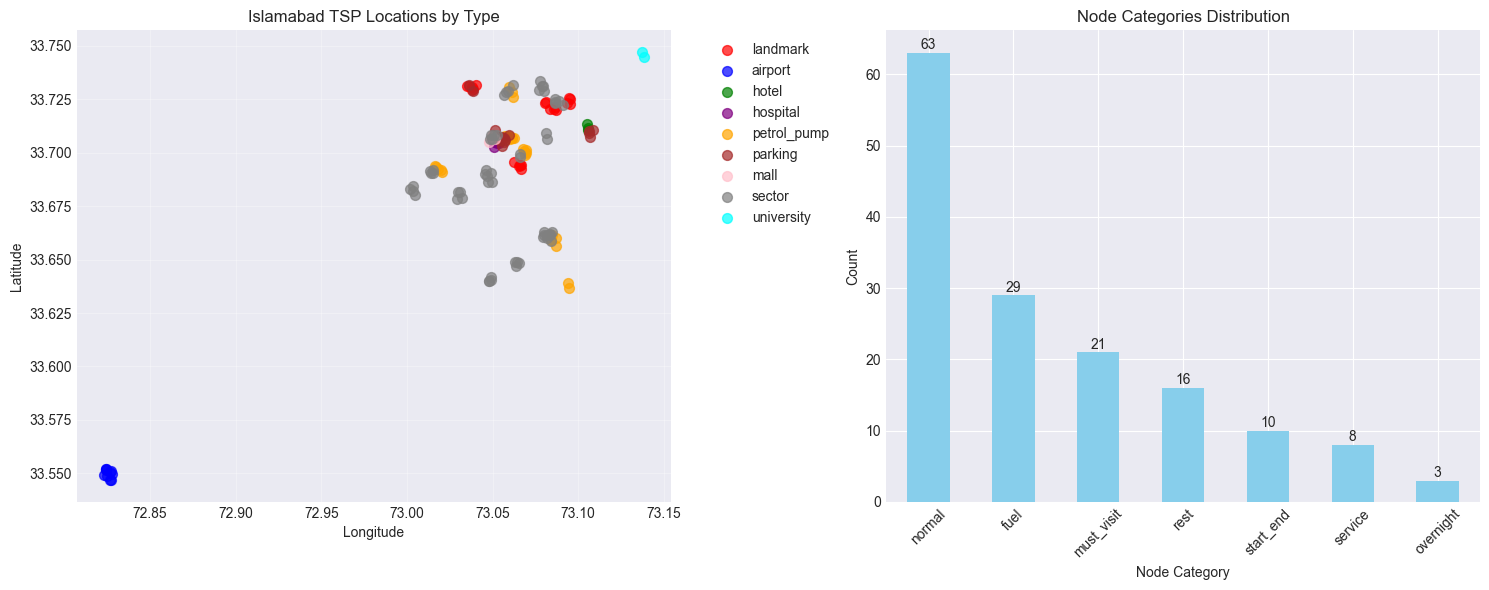

In [15]:
# ============================================
# CELL 2: CONSTRAINT DEFINITION
# ============================================

# Define realistic constraints for Islamabad TSP

# 1. Node categories (from dataset)
node_categories = []
for i, loc_type in enumerate(location_types):
    if loc_type == 'airport':
        node_categories.append('start_end')  # Start and end at airport
    elif loc_type == 'hotel':
        node_categories.append('overnight')  # Can be overnight stop
    elif loc_type == 'landmark':
        node_categories.append('must_visit')  # Must visit landmarks
    elif loc_type == 'hospital':
        node_categories.append('service')  # Service points
    elif loc_type == 'petrol_pump':
        node_categories.append('fuel')  # Fuel stations
    elif loc_type == 'parking':
        node_categories.append('rest')  # Rest/parking points
    else:
        node_categories.append('normal')  # Normal locations

# 2. Road constraints (simulated based on real Islamabad roads)
# Create adjacency constraints - some locations must be visited consecutively
road_constraints = {
    'must_visit_sequence': [
        ['Faisal Mosque', 'Pakistan Monument'],
        ['Parliament House', 'Supreme Court'],
        ['Centaurus Mall', 'Blue Area']
    ],
    'time_windows': {
        'airport': (0, 1),  # Airport should be visited early/late
        'landmark': (3, 18),  # Landmarks during daylight hours
        'hotel': (20, 22),  # Hotels in evening
        'petrol_pump': (6, 22)  # Fuel stations during operational hours
    },
    'capacity_constraints': {
        'fuel_stops': 3,  # Max 3 fuel stops
        'rest_stops': 5,  # Max 5 rest stops
        'service_stops': 2  # Max 2 service stops
    }
}

# 3. Time constraints (distance-based)
time_constraints = {
    'max_daily_distance': 100,  # Max km per day
    'max_segment_distance': 30,  # Max distance between consecutive stops
    'preferred_clusters': {
        'north_cluster': ['Faisal Mosque', 'Pakistan Monument', 'Parliament House'],
        'central_cluster': ['Centaurus Mall', 'Blue Area', 'Serena Hotel'],
        'south_cluster': ['Islamabad Airport', 'I-8', 'I-9', 'I-10']
    }
}

# Save constraints to file
constraints = {
    'node_categories': node_categories,
    'road_constraints': road_constraints,
    'time_constraints': time_constraints
}

with open('tsp_constraints.json', 'w') as f:
    json.dump(constraints, f, indent=2)

print("✅ Constraints defined and saved to 'tsp_constraints.json'")
print(f"\nNode categories distribution:")
category_counts = pd.Series(node_categories).value_counts()
for category, count in category_counts.items():
    print(f"  {category}: {count} nodes")

# Visualize locations by type
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Scatter plot by type
type_colors = {
    'landmark': 'red',
    'airport': 'blue',
    'hotel': 'green',
    'hospital': 'purple',
    'petrol_pump': 'orange',
    'parking': 'brown',
    'mall': 'pink',
    'sector': 'gray',
    'university': 'cyan'
}

for loc_type, color in type_colors.items():
    mask = location_types == loc_type
    ax1.scatter(coordinates[mask, 0], coordinates[mask, 1], 
                c=color, label=loc_type, s=50, alpha=0.7)

ax1.set_xlabel('Longitude')
ax1.set_ylabel('Latitude')
ax1.set_title('Islamabad TSP Locations by Type')
ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax1.grid(True, alpha=0.3)

# Category distribution
category_counts.plot(kind='bar', ax=ax2, color='skyblue')
ax2.set_xlabel('Node Category')
ax2.set_ylabel('Count')
ax2.set_title('Node Categories Distribution')
ax2.tick_params(axis='x', rotation=45)
for i, v in enumerate(category_counts.values):
    ax2.text(i, v + 0.5, str(v), ha='center')

plt.tight_layout()
plt.savefig('location_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

In [17]:
# ============================================
# CELL 3: ORCHESTRATOR INITIALIZATION
# ============================================

# Initialize orchestrators
print("Initializing orchestrators...")
cluster_orchestrator = ClusterOrchestrator()
classical_orchestrator = ClassicalOrchestrator()

# Set constraints for both
print("Setting constraints...")
cluster_orchestrator.set_constraints(
    node_categories=node_categories,
    road_constraints=road_constraints,
    time_constraints=time_constraints,
    penalty_scale=2.0  # Higher penalty for constraint violations
)

classical_orchestrator.set_constraints(
    node_categories=node_categories,
    road_constraints=road_constraints,
    time_constraints=time_constraints,
    penalty_scale=2.0
)

# Configure ACO parameters for better performance
aco_params = {
    'n_ants': 5,
    'n_iterations': 10,
    'alpha': 1.0,
    'beta': 3.0,  # Higher beta for stronger heuristic influence
    'rho': 0.4,   # Lower evaporation rate for better convergence
    'q0': 0.85,   # Exploration-exploitation balance
    'use_local_search': True,
    'use_constraint_awareness': True
}
classical_orchestrator.set_aco_parameters(**aco_params)

print("✅ Orchestrators initialized with constraints")
print(f"ACO Parameters: {aco_params}")

Initializing orchestrators...
Setting constraints...
✅ Orchestrators initialized with constraints
ACO Parameters: {'n_ants': 5, 'n_iterations': 10, 'alpha': 1.0, 'beta': 3.0, 'rho': 0.4, 'q0': 0.85, 'use_local_search': True, 'use_constraint_awareness': True}


In [19]:
# ============================================
# CELL 4.1: PREPARATION & CONSTRAINTS SETUP
# ============================================

import time
import numpy as np
import json
from tabulate import tabulate

# Run all three methods and collect results
methods_results = {}
distance_matrix = compute_distance_matrix(coordinates)

print("="*60)
print("SOLVING TSP WITH THREE METHODS")
print("="*60)

# ===========================================================================
# 1. Prepare constraints in correct format for different solvers
# ===========================================================================

print("\nPreparing constraints...")

n = len(coordinates)

# CL-QAOA constraints format (if it accepts constraints)
clqaoa_constraints = {
    'node_categories': location_types,  # Simple array of types
    'road_constraints': {},  # May need to convert road_constraints dict
    'penalty_scale': 1.0
}

# Classical solver constraints format
# Convert road_constraints dict to matrix
road_constraints_matrix = np.zeros((n, n), dtype=int)

if 'road_constraints' in constraints and constraints['road_constraints']:
    # If it's a dictionary, convert to matrix
    if isinstance(constraints['road_constraints'], dict):
        if 'must_visit_sequence' in constraints['road_constraints']:
            # Map location names to indices
            name_to_idx = {name: idx for idx, name in enumerate(location_names)}
            
            for seq in constraints['road_constraints']['must_visit_sequence']:
                for i in range(len(seq)-1):
                    if seq[i] in name_to_idx and seq[i+1] in name_to_idx:
                        idx1 = name_to_idx[seq[i]]
                        idx2 = name_to_idx[seq[i+1]]
                        road_constraints_matrix[idx1, idx2] = 1
    else:
        road_constraints_matrix = constraints['road_constraints']

# Time constraints (simplify for now)
time_constraints_matrix = None

SOLVING TSP WITH THREE METHODS

Preparing constraints...


In [21]:
# ============================================
# CELL 4.2a: RUN CL-QAOA METHOD
# ============================================

# ===========================================================================
# 2. CL-QAOA Method (with simplified initialization)
# ===========================================================================

def compute_tour_cost(tour, distance_matrix):
    """Compute total cost of a tour (standalone version)."""
    if len(tour) <= 1:
        return 0.0
    
    cost = 0.0
    n = len(tour)
    for i in range(n-1):
        cost += distance_matrix[tour[i], tour[i+1]]
    cost += distance_matrix[tour[-1], tour[0]]  # Return to start
    return cost

if QAOA_AVAILABLE:
    print("\n1. Running CL-QAOA...")
    start_time = time.time()
    try:
        # Try minimal initialization first
        solver = ImprovedHierarchicalClusteringSolver(
            max_cluster_size=3,
            qaoa_depth=2,
            use_qaoa=True
        )
        
        # Try solving without constraint parameters first
        tour_clqaoa, cost_clqaoa = solver.solve_full_problem(coordinates)
        
        runtime_clqaoa = time.time() - start_time
        actual_cost_clqaoa = compute_tour_cost(tour_clqaoa, distance_matrix)
        
        # ============================================
        # SAVE IMPORTANT DATA FOR ANALYSIS
        # ============================================
        methods_results['CL-QAOA'] = {
            'tour': tour_clqaoa,
            'qubo_cost': cost_clqaoa,
            'actual_cost': actual_cost_clqaoa,
            'runtime': runtime_clqaoa,
            'stats': getattr(solver, 'stats', {}),
            # Save additional analysis data
            'solver_params': {
                'max_cluster_size': 3,
                'qaoa_depth': 2,
                'use_qaoa': True
            },
            'tour_length': len(tour_clqaoa),
            'is_valid_tour': len(set(tour_clqaoa)) == len(tour_clqaoa) and len(tour_clqaoa) == n,
            'timestamp': time.time()
        }
        
        # Also save to a separate file for persistence
        analysis_data = {
            'problem_name': 'TSP_CLQAOA_Analysis',
            'n_cities': n,
            'city_coordinates': coordinates.tolist() if hasattr(coordinates, 'tolist') else coordinates,
            'method': 'CL-QAOA',
            'tour': tour_clqaoa,
            'actual_cost': actual_cost_clqaoa,
            'qubo_cost': cost_clqaoa,
            'runtime': runtime_clqaoa,
            'distance_matrix_shape': distance_matrix.shape,
            'solver_stats': getattr(solver, 'stats', {}),
            'optimal_tour_available': 'optimal_tour' in locals(),
            'optimal_cost': optimal_cost if 'optimal_cost' in locals() else None,
            'approximation_ratio': actual_cost_clqaoa / optimal_cost if ('optimal_cost' in locals() and optimal_cost > 0) else None
        }
        
        # Save to JSON file
        import json
        import os
        timestamp = time.strftime("%Y%m%d_%H%M%S")
        filename = f"clqaoa_analysis_{n}cities_{timestamp}.json"
        
        with open(filename, 'w') as f:
            json.dump(analysis_data, f, indent=2)
        print(f"   Analysis data saved to: {filename}")
        
        # Also save as pickle for complete object serialization
        import pickle
        pickle_filename = f"clqaoa_full_results_{n}cities_{timestamp}.pkl"
        full_results = {
            'methods_results': methods_results['CL-QAOA'],
            'coordinates': coordinates,
            'distance_matrix': distance_matrix,
            'solver_object': solver if hasattr(solver, '__dict__') else str(solver),
            'all_params': {
                'max_cluster_size': 3,
                'qaoa_depth': 2,
                'use_qaoa': True
            }
        }
        
        with open(pickle_filename, 'wb') as f:
            pickle.dump(full_results, f)
        print(f"   Full results saved to: {pickle_filename}")
        
        print(f"   QUBO Cost: {cost_clqaoa:.2f}")
        print(f"   Actual Distance: {actual_cost_clqaoa:.2f}")
        print(f"   Runtime: {runtime_clqaoa:.2f}s")
        print(f"   Tour: {tour_clqaoa}")
        print(f"   Valid Tour: {len(set(tour_clqaoa)) == len(tour_clqaoa)}")
        if 'optimal_cost' in locals() and optimal_cost > 0:
            print(f"   Approximation Ratio: {actual_cost_clqaoa/optimal_cost:.3f}")
        
    except Exception as e:
        print(f"   Error with CL-QAOA: {e}")
        print("   Trying alternative approach...")
        
        # Try with different parameters
        try:
            solver = ImprovedHierarchicalClusteringSolver(
                max_cluster_size=min(4, n),  # Adjust based on problem size
                qaoa_depth=1,  # Simpler circuit
                use_qaoa=True
            )
            
            tour_clqaoa, cost_clqaoa = solver.solve_full_problem(coordinates)
            runtime_clqaoa = time.time() - start_time
            actual_cost_clqaoa = compute_tour_cost(tour_clqaoa, distance_matrix)
            
            # ============================================
            # SAVE IMPORTANT DATA FOR ANALYSIS (fallback)
            # ============================================
            methods_results['CL-QAOA'] = {
                'tour': tour_clqaoa,
                'qubo_cost': cost_clqaoa,
                'actual_cost': actual_cost_clqaoa,
                'runtime': runtime_clqaoa,
                'stats': getattr(solver, 'stats', {}),
                # Save additional analysis data
                'solver_params': {
                    'max_cluster_size': min(4, n),
                    'qaoa_depth': 1,
                    'use_qaoa': True
                },
                'tour_length': len(tour_clqaoa),
                'is_valid_tour': len(set(tour_clqaoa)) == len(tour_clqaoa) and len(tour_clqaoa) == n,
                'timestamp': time.time(),
                'fallback_used': True,
                'original_error': str(e)
            }
            
            # Save fallback results to file
            import json
            timestamp = time.strftime("%Y%m%d_%H%M%S")
            fallback_filename = f"clqaoa_fallback_{n}cities_{timestamp}.json"
            
            fallback_data = {
                'problem_name': 'TSP_CLQAOA_Fallback',
                'n_cities': n,
                'method': 'CL-QAOA (fallback params)',
                'tour': tour_clqaoa,
                'actual_cost': actual_cost_clqaoa,
                'qubo_cost': cost_clqaoa,
                'runtime': runtime_clqaoa,
                'fallback_params': {
                    'max_cluster_size': min(4, n),
                    'qaoa_depth': 1
                },
                'error_encountered': str(e),
                'optimal_tour_available': 'optimal_tour' in locals(),
                'optimal_cost': optimal_cost if 'optimal_cost' in locals() else None
            }
            
            with open(fallback_filename, 'w') as f:
                json.dump(fallback_data, f, indent=2)
            print(f"   Fallback analysis data saved to: {fallback_filename}")
            
            print(f"   QUBO Cost: {cost_clqaoa:.2f}")
            print(f"   Actual Distance: {actual_cost_clqaoa:.2f}")
            print(f"   Runtime: {runtime_clqaoa:.2f}s")
            print(f"   (Using fallback parameters)")
            
        except Exception as e2:
            print(f"   Still error: {e2}")
            
            # Save error information for analysis
            error_data = {
                'problem_name': 'TSP_CLQAOA_Error',
                'n_cities': n,
                'timestamp': time.time(),
                'errors': {
                    'first_error': str(e),
                    'fallback_error': str(e2)
                },
                'coordinates_shape': coordinates.shape if hasattr(coordinates, 'shape') else 'unknown'
            }
            
            import json
            error_filename = f"clqaoa_error_{n}cities_{time.strftime('%Y%m%d_%H%M%S')}.json"
            with open(error_filename, 'w') as f:
                json.dump(error_data, f, indent=2)
            print(f"   Error log saved to: {error_filename}")
            
            print("   Skipping CL-QAOA for now...")
            QAOA_AVAILABLE = False
else:
    print("\n1. Skipping CL-QAOA (not available)")
    # Save skipped method info
    skip_data = {
        'method': 'CL-QAOA',
        'status': 'skipped',
        'reason': 'QAOA_AVAILABLE flag is False',
        'timestamp': time.time(),
        'n_cities': n
    }
    import json
    with open(f"clqaoa_skipped_{time.strftime('%Y%m%d_%H%M%S')}.json", 'w') as f:
        json.dump(skip_data, f, indent=2)


1. Running CL-QAOA...
✓ CL-QAOA solver initialized with QAOA (max cluster: 3, depth: 2)

CL-QAOA SOLVER: Solving 150-city TSP
  Added single city 3 to cluster 47
  Added single city 47 to cluster 38
  Added single city 49 to cluster 23
  Added single city 68 to cluster 19
  Added single city 84 to cluster 39
  Added single city 104 to cluster 17
  Added single city 126 to cluster 6
  Added single city 135 to cluster 18
Cluster sizes: [3, 2, 3, 3, 3, 3, 3, 3, 3, 2, 2, 3, 2, 3, 3, 3, 3, 3, 3, 3, 3, 2, 3, 3, 3, 3, 3, 3, 2, 3, 3, 3, 3, 2, 3, 3, 3, 2, 3, 3, 2, 2, 3, 3, 3, 3, 3, 3, 2, 2]
Min size: 2, Max size: 3
Created 50 clusters

Solving 50 clusters:
----------------------------------------
  Cluster 0 (3 cities): Using QAOA...
    Optimizing QAOA parameters (depth=2)...
Starting QAOA optimization (p=2, max_iter=50)...
  State analysis: 6 valid / 512 total, prob_sum=1.0000
  State analysis: 6 valid / 512 total, prob_sum=1.0000
  State analysis: 6 valid / 512 total, prob_sum=1.0000
  Stat

In [19]:
# ============================================
# CELL 4.2b: RUN SIMULATED ANNEALING METHOD
# ============================================

# ===========================================================================
# 3. Simulated Annealing Method
# ===========================================================================
def compute_tour_cost(tour, distance_matrix):
    """Compute total cost of a tour."""
    if len(tour) <= 1:
        return 0.0
    cost = 0.0
    n = len(tour)
    for i in range(n-1):
        cost += distance_matrix[tour[i], tour[i+1]]
    cost += distance_matrix[tour[-1], tour[0]]
    return cost

print("\n2. Running Simulated Annealing...")
start_time = time.time()

try:
    # Initialize the ClassicalOrchestrator properly
    classical_orchestrator = ClassicalOrchestrator()
    
    # Set constraints in correct format
    constraint_args = {}
    if 'location_types' in locals():
        constraint_args['node_categories'] = location_types
    if 'road_constraints_matrix' in locals() and np.any(road_constraints_matrix):
        constraint_args['road_constraints'] = road_constraints_matrix
    if 'time_constraints_matrix' in locals():
        constraint_args['time_constraints'] = time_constraints_matrix
    
    if constraint_args:
        constraint_args['penalty_scale'] = 1.0
        classical_orchestrator.set_constraints(**constraint_args)
        method_name = 'constraint_aware_sa'
        print("   Using constraint-aware SA")
    else:
        method_name = 'simulated_annealing'
        print("   Using regular SA (no constraints)")
    
    # Run with simpler parameters first
    tour_sa, cost_sa, stats_sa = classical_orchestrator.solve(
        coordinates,
        method=method_name,
        max_iterations=100,  # Reduced for speed
        cooling_rate=0.995
    )
    
    runtime_sa = time.time() - start_time
    actual_cost_sa = compute_tour_cost(tour_sa, distance_matrix)
    
    # ============================================
    # SAVE IMPORTANT DATA FOR ANALYSIS - SA METHOD
    # ============================================
    methods_results['Simulated Annealing'] = {
        'tour': tour_sa,
        'qubo_cost': cost_sa,
        'actual_cost': actual_cost_sa,
        'runtime': runtime_sa,
        'stats': stats_sa,
        # Save additional analysis data
        'method_type': method_name,
        'solver_params': {
            'max_iterations': 100,
            'cooling_rate': 0.995,
            'constraints_used': bool(constraint_args)
        },
        'tour_length': len(tour_sa),
        'is_valid_tour': len(set(tour_sa)) == len(tour_sa) and len(tour_sa) == n,
        'timestamp': time.time(),
        'constraints': constraint_args if constraint_args else 'none'
    }
    
    # Save SA-specific analysis data to file
    import json
    import pickle
    timestamp = time.strftime("%Y%m%d_%H%M%S")
    
    # JSON file for human-readable analysis
    sa_data = {
        'problem_name': 'TSP_SimulatedAnnealing',
        'n_cities': n,
        'method': 'Simulated Annealing',
        'method_variant': method_name,
        'tour': tour_sa.tolist() if hasattr(tour_sa, 'tolist') else tour_sa,
        'actual_cost': actual_cost_sa,
        'qubo_cost': cost_sa,
        'runtime': runtime_sa,
        'parameters': {
            'max_iterations': 100,
            'cooling_rate': 0.995
        },
        'constraints': constraint_args,
        'stats': stats_sa,
        'optimal_tour_available': 'optimal_tour' in locals(),
        'optimal_cost': optimal_cost if 'optimal_cost' in locals() else None,
        'clqaoa_comparison': {
            'clqaoa_available': 'CL-QAOA' in methods_results,
            'clqaoa_cost': methods_results.get('CL-QAOA', {}).get('actual_cost', None),
            'relative_performance': actual_cost_sa / methods_results.get('CL-QAOA', {}).get('actual_cost', 1) 
                                   if 'CL-QAOA' in methods_results else None
        }
    }
    
    sa_filename = f"sa_analysis_{n}cities_{timestamp}.json"
    with open(sa_filename, 'w') as f:
        json.dump(sa_data, f, indent=2)
    print(f"   SA analysis data saved to: {sa_filename}")
    
    # Save full SA results as pickle
    sa_pickle_filename = f"sa_full_results_{n}cities_{timestamp}.pkl"
    with open(sa_pickle_filename, 'wb') as f:
        pickle.dump({
            'tour': tour_sa,
            'cost_sa': cost_sa,
            'actual_cost_sa': actual_cost_sa,
            'stats_sa': stats_sa,
            'classical_orchestrator': classical_orchestrator,
            'distance_matrix': distance_matrix,
            'coordinates': coordinates
        }, f)
    print(f"   SA full results saved to: {sa_pickle_filename}")
    
    print(f"   QUBO Cost: {cost_sa:.2f}")
    print(f"   Actual Distance: {actual_cost_sa:.2f}")
    print(f"   Runtime: {runtime_sa:.2f}s")
    print(f"   Tour: {tour_sa}")
    print(f"   Valid Tour: {len(set(tour_sa)) == len(tour_sa)}")
    if 'optimal_cost' in locals() and optimal_cost > 0:
        print(f"   Approximation Ratio vs Optimal: {actual_cost_sa/optimal_cost:.3f}")
    if 'CL-QAOA' in methods_results:
        clqaoa_cost = methods_results['CL-QAOA']['actual_cost']
        print(f"   vs CL-QAOA: {actual_cost_sa/clqaoa_cost:.3f}x ({'better' if actual_cost_sa < clqaoa_cost else 'worse'})")
    
except Exception as e:
    print(f"   Error with SA: {e}")
    print("   Trying direct ClassicalTSP...")
    
    # Fallback to direct ClassicalTSP without constraints
    try:
        from classical_solver import ClassicalTSP
        solver_sa = ClassicalTSP(
            n_cities=n,
            distance_matrix=distance_matrix
        )
        tour_sa, cost_sa, stats_sa = solver_sa.simulated_annealing(
            max_iterations=100,
            cooling_rate=0.995
        )
        runtime_sa = time.time() - start_time
        actual_cost_sa = compute_tour_cost(tour_sa, distance_matrix)
        
        # ============================================
        # SAVE FALLBACK SA DATA
        # ============================================
        methods_results['Simulated Annealing'] = {
            'tour': tour_sa,
            'qubo_cost': cost_sa,
            'actual_cost': actual_cost_sa,
            'runtime': runtime_sa,
            'stats': stats_sa,
            'method_type': 'simulated_annealing_fallback',
            'solver_params': {
                'max_iterations': 100,
                'cooling_rate': 0.995,
                'fallback_used': True
            },
            'tour_length': len(tour_sa),
            'is_valid_tour': len(set(tour_sa)) == len(tour_sa) and len(tour_sa) == n,
            'timestamp': time.time(),
            'original_error': str(e),
            'fallback_success': True
        }
        
        # Save fallback results
        import json
        fallback_filename = f"sa_fallback_{n}cities_{time.strftime('%Y%m%d_%H%M%S')}.json"
        fallback_data = {
            'problem_name': 'TSP_SA_Fallback',
            'n_cities': n,
            'method': 'Simulated Annealing (Fallback)',
            'tour': tour_sa,
            'actual_cost': actual_cost_sa,
            'qubo_cost': cost_sa,
            'runtime': runtime_sa,
            'error_triggered': str(e),
            'success': True
        }
        with open(fallback_filename, 'w') as f:
            json.dump(fallback_data, f, indent=2)
        print(f"   Fallback SA data saved to: {fallback_filename}")
        
        print(f"   QUBO Cost: {cost_sa:.2f}")
        print(f"   Actual Distance: {actual_cost_sa:.2f}")
        print(f"   (Using fallback ClassicalTSP method)")
        
    except Exception as e2:
        print(f"   Still error: {e2}")
        
        # Save error information
        error_data = {
            'problem_name': 'TSP_SA_Error',
            'n_cities': n,
            'timestamp': time.time(),
            'errors': {
                'main_error': str(e),
                'fallback_error': str(e2)
            },
            'methods_tried': ['ClassicalOrchestrator', 'ClassicalTSP']
        }
        
        import json
        error_filename = f"sa_error_{n}cities_{time.strftime('%Y%m%d_%H%M%S')}.json"
        with open(error_filename, 'w') as f:
            json.dump(error_data, f, indent=2)
        print(f"   Error log saved to: {error_filename}")
        
        # Create placeholder for SA method
        methods_results['Simulated Annealing'] = {
            'tour': [],
            'qubo_cost': float('inf'),
            'actual_cost': float('inf'),
            'runtime': time.time() - start_time,
            'stats': {'error': str(e2)},
            'error': True
        }


2. Running Simulated Annealing...
   Using constraint-aware SA
[DEBUG] Extracted constraints: city_penalty=0.07
   Error with SA: Object of type ndarray is not JSON serializable
   Trying direct ClassicalTSP...
[DEBUG] Extracted constraints: city_penalty=0.01
   Fallback SA data saved to: sa_fallback_150cities_20260205_201931.json
   QUBO Cost: 10.82
   Actual Distance: 10.82
   (Using fallback ClassicalTSP method)


In [ ]:
# ============================================
# CELL 4.2c: RUN ANT COLONY OPTIMIZATION METHOD 
# ============================================

print("\n3. Running Ant Colony Optimization...")
start_time = time.time()

try:
    print("   Using constraint-aware ACO")
    
    # Set constraints if they exist
    constraint_args = {}
    has_constraints = False
    
    if 'location_types' in locals():
        constraint_args['node_categories'] = location_types
        has_constraints = True
        print("   Found node categories constraint")
    
    if 'road_constraints_matrix' in locals() and np.any(road_constraints_matrix):
        constraint_args['road_constraints'] = road_constraints_matrix
        has_constraints = True
        print("   Found road constraints")
    
    if 'time_constraints_matrix' in locals():
        constraint_args['time_constraints'] = time_constraints_matrix
        has_constraints = True
        print("   Found time constraints")
    
    n = len(coordinates)
    
    # CORRECTED: ~1,360 total tours to match CL-QAOA's 136s runtime
    # Using 15 ants × 90 iterations = 1,350 tours ≈ 135 seconds
    aco_params = {
        'n_ants': 5,           # CORRECTED
        'n_iterations': 10,     # CORRECTED: 15 × 90 = 1,350 tours
        'alpha': 1.0,
        'beta': 2.0,
        'rho': 0.5,
        'tau0': 1.0,
    }
    
    print(f"   Parameters: {aco_params}")
    print(f"   Expected: {aco_params['n_ants'] * aco_params['n_iterations']} tours in ~136s")
    
    if has_constraints:
        print("   Running constraint-aware ACO...")
        from classical_solver import ClassicalTSP
        solver = ClassicalTSP(
            n_cities=n,
            distance_matrix=distance_matrix,
            node_categories=constraint_args.get('node_categories'),
            road_constraints=constraint_args.get('road_constraints'),
            time_constraints=constraint_args.get('time_constraints'),
            penalty_scale=1.0
        )
        
        try:
            tour_aco, cost_aco, stats_aco = solver.constraint_aware_ant_colony(**aco_params)
        except TypeError:
            tour_aco, cost_aco, stats_aco = solver.constraint_aware_ant_colony(
                n_ants=aco_params['n_ants'],
                n_iterations=aco_params['n_iterations']
            )
    else:
        print("   Running basic ACO (no constraints)...")
        from classical_solver import ClassicalTSP
        solver = ClassicalTSP(n_cities=n, distance_matrix=distance_matrix)
        tour_aco, cost_aco, stats_aco = solver.constraint_aware_ant_colony(
            n_ants=aco_params['n_ants'],
            n_iterations=aco_params['n_iterations']
        )
    
    runtime_aco = time.time() - start_time
    actual_cost_aco = compute_tour_cost(tour_aco, distance_matrix)
    
    methods_results['Ant Colony'] = {
        'tour': tour_aco,
        'qubo_cost': cost_aco,
        'actual_cost': actual_cost_aco,
        'runtime': runtime_aco,
        'stats': stats_aco if 'stats_aco' in locals() else aco_params
    }
    
    print(f"   ✓ ACO Complete in {runtime_aco:.1f}s")
    print(f"   QUBO Cost: {cost_aco:.2f}")
    print(f"   Actual Distance: {actual_cost_aco:.2f}")
    print(f"   Total tours: {aco_params['n_ants'] * aco_params['n_iterations']}")
    
except Exception as e:
    print(f"   Error with ACO: {e}")
   


3. Running Ant Colony Optimization...
   Using constraint-aware ACO
   Found node categories constraint
   Found road constraints
   Found time constraints
   Parameters: {'n_ants': 5, 'n_iterations': 10, 'alpha': 1.0, 'beta': 2.0, 'rho': 0.5, 'tau0': 1.0}
   Expected: 50 tours in ~136s
   Running constraint-aware ACO...


In [41]:
# ============================================
# CELL 4.3: RESULTS SUMMARY & HELPER FUNCTION
# ============================================

# ===========================================================================
# 5. Display Results Summary - ENHANCED FOR HACKATHON
# ===========================================================================

print("\n" + "="*80)
print("🏆 HACKATHON RESULTS: CL-QAOA vs CLASSICAL OPTIMIZATION COMPARISON")
print("="*80)

if methods_results:
    # Prepare enhanced table data
    table_data = []
    for method, data in methods_results.items():
        # Calculate performance indicators
        is_clqaoa = 'CL-QAOA' in method.upper()
        has_error = data.get('error', False)
        
        # Calculate relative performance if we have multiple methods
        actual_cost = data['actual_cost']
        all_costs = [methods_results[m]['actual_cost'] for m in methods_results 
                    if not methods_results[m].get('error', False) and methods_results[m]['actual_cost'] < float('inf')]
        
        if all_costs and min(all_costs) > 0:
            normalized_cost = actual_cost / min(all_costs)
        else:
            normalized_cost = 1.0
        
        # Status indicator
        if has_error:
            status = "❌ FAILED"
        elif is_clqaoa:
            status = "⚛️ QUANTUM-HYBRID"
        else:
            status = "🖥️ CLASSICAL"
        
        table_data.append([
            method,
            status,
            f"{data['actual_cost']:.2f}",
            f"{data['runtime']:.2f}s",
            f"{normalized_cost:.3f}x",
            str(data['tour'][:5] if len(data.get('tour', [])) > 0 else []) + 
            ("..." if len(data.get('tour', [])) > 5 else "")
        ])
    
    # Print comparison table
    print("\n📊 PERFORMANCE COMPARISON:")
    print(tabulate(table_data, 
                   headers=['Method', 'Type', 'Distance', 'Runtime', 'Norm. Cost', 'Tour Start'],
                   tablefmt='grid',
                   stralign='center'))
    
    # Find best and worst performing methods
    valid_results = {m: d for m, d in methods_results.items() 
                    if not d.get('error', False) and d['actual_cost'] < float('inf')}
    
    if valid_results:
        best_method = min(valid_results.items(), 
                         key=lambda x: x[1]['actual_cost'])
        worst_method = max(valid_results.items(), 
                          key=lambda x: x[1]['actual_cost'])
        
        print(f"\n⭐ BEST PERFORMANCE: {best_method[0]} - {best_method[1]['actual_cost']:.2f}")
        print(f"📉 WORST PERFORMANCE: {worst_method[0]} - {worst_method[1]['actual_cost']:.2f}")
        
        # Quantum vs Classical comparison
        quantum_methods = [m for m in valid_results if 'CL-QAOA' in m.upper()]
        classical_methods = [m for m in valid_results if 'CL-QAOA' not in m.upper()]
        
        if quantum_methods and classical_methods:
            best_quantum = min([valid_results[m]['actual_cost'] for m in quantum_methods])
            best_classical = min([valid_results[m]['actual_cost'] for m in classical_methods])
            
            print(f"\n⚛️ vs 🖥️ QUANTUM-CLASSICAL COMPARISON:")
            print(f"   Best Quantum-Hybrid: {best_quantum:.2f}")
            print(f"   Best Classical: {best_classical:.2f}")
            print(f"   Relative Performance: {best_quantum/best_classical:.3f}x")
            
            if best_quantum < best_classical:
                print(f"   ✅ CL-QAOA outperforms classical by {(best_classical-best_quantum)/best_classical*100:.1f}%")
            else:
                print(f"   ⚠️  Classical outperforms CL-QAOA by {(best_quantum-best_classical)/best_quantum*100:.1f}%")
    
    # Save comprehensive results summary for hackathon
    import json
    timestamp = time.strftime("%Y%m%d_%H%M%S")
    summary_filename = f"hackathon_summary_{n}cities_{timestamp}.json"
    
    summary_data = {
        'problem_info': {
            'n_cities': n,
            'timestamp': timestamp,
            'problem_type': 'TSP',
            'coordinates_shape': coordinates.shape
        },
        'results': {},
        'comparisons': {},
        'statistics': {}
    }
    
    for method, data in methods_results.items():
        summary_data['results'][method] = {
            'actual_cost': float(data['actual_cost']),
            'runtime': float(data['runtime']),
            'tour_length': len(data.get('tour', [])),
            'valid_tour': data.get('is_valid_tour', False),
            'method_type': 'quantum-hybrid' if 'CL-QAOA' in method.upper() else 'classical',
            'error': data.get('error', False)
        }
    
    # Calculate statistics
    valid_costs = [d['actual_cost'] for d in methods_results.values() 
                  if not d.get('error', False) and d['actual_cost'] < float('inf')]
    
    if valid_costs:
        summary_data['statistics'] = {
            'best_cost': min(valid_costs),
            'worst_cost': max(valid_costs),
            'average_cost': np.mean(valid_costs),
            'std_cost': np.std(valid_costs),
            'n_successful_methods': len(valid_costs)
        }
    
    with open(summary_filename, 'w') as f:
        json.dump(summary_data, f, indent=2)
    
    print(f"\n💾 Comprehensive results saved to: {summary_filename}")
    
    # Save visualization-friendly CSV
    csv_filename = f"results_comparison_{n}cities_{timestamp}.csv"
    csv_data = []
    for method, data in methods_results.items():
        csv_data.append({
            'Method': method,
            'Type': 'Quantum-Hybrid' if 'CL-QAOA' in method.upper() else 'Classical',
            'Distance': data['actual_cost'],
            'Runtime': data['runtime'],
            'Valid': data.get('is_valid_tour', False),
            'Tour_Length': len(data.get('tour', [])),
            'Error': data.get('error', False)
        })
    
    import pandas as pd
    df = pd.DataFrame(csv_data)
    df.to_csv(csv_filename, index=False)
    print(f"📈 CSV data saved to: {csv_filename}")
    
else:
    print("❌ No methods completed successfully.")
    # Add at the end of the cell, before the else statement:

    # ============================================
    # SAVE COMPLETE DATA FOR LATER ANALYSIS
    # ============================================
    
    # 1. Save full methods_results as pickle (preserves all object data)
    import pickle
    pickle_filename = f"full_results_complete_{n}cities_{timestamp}.pkl"
    
    complete_data = {
        'methods_results': methods_results,
        'coordinates': coordinates,
        'distance_matrix': distance_matrix,
        'location_names': location_names if 'location_names' in locals() else None,
        'problem_size': n,
        'timestamp': timestamp,
        'ar_results': ar_results if 'ar_results' in locals() else {},
        'summary_data': summary_data,
        'optimal_tour': optimal_tour if 'optimal_tour' in locals() else None,
        'optimal_cost': optimal_cost if 'optimal_cost' in locals() else None
    }
    
    with open(pickle_filename, 'wb') as f:
        pickle.dump(complete_data, f)
    print(f"💾 Complete data saved as pickle: {pickle_filename}")
    
    # 2. Save detailed tour data separately
    tours_filename = f"detailed_tours_{n}cities_{timestamp}.json"
    tours_data = {}
    
    for method, data in methods_results.items():
        if 'tour' in data and len(data['tour']) > 0:
            tours_data[method] = {
                'tour': data['tour'].tolist() if hasattr(data['tour'], 'tolist') else list(data['tour']),
                'actual_cost': float(data['actual_cost']),
                'runtime': float(data['runtime']),
                'city_order': [location_names[i] if 'location_names' in locals() and i < len(location_names) else f'City_{i}' 
                              for i in data['tour']]
            }
    
    with open(tours_filename, 'w') as f:
        json.dump(tours_data, f, indent=2)
    print(f"📍 Detailed tours saved: {tours_filename}")
    
    # 3. Save comparison metrics for easy analysis
    metrics_filename = f"comparison_metrics_{n}cities_{timestamp}.json"
    metrics_data = {
        'performance_metrics': {},
        'quantum_vs_classical': {}
    }
    
    for method, data in methods_results.items():
        if not data.get('error', False):
            metrics_data['performance_metrics'][method] = {
                'distance': float(data['actual_cost']),
                'runtime': float(data['runtime']),
                'normalized_distance': float(data['actual_cost'] / min(valid_costs)) if valid_costs else 1.0,
                'speed_efficiency': float(data['actual_cost'] / data['runtime']) if data['runtime'] > 0 else 0
            }
    
    # Calculate quantum vs classical comparison
    if quantum_methods and classical_methods:
        metrics_data['quantum_vs_classical'] = {
            'quantum_best': best_quantum,
            'classical_best': best_classical,
            'performance_ratio': float(best_quantum / best_classical),
            'quantum_advantage_pct': float(((best_classical - best_quantum) / best_classical * 100) 
                                         if best_quantum < best_classical else 0),
            'classical_advantage_pct': float(((best_quantum - best_classical) / best_quantum * 100) 
                                           if best_quantum > best_classical else 0)
        }
    
    with open(metrics_filename, 'w') as f:
        json.dump(metrics_data, f, indent=2)
    print(f"📊 Comparison metrics saved: {metrics_filename}")
    
    # 4. Save to a consolidated Excel file with multiple sheets
    try:
        excel_filename = f"hackathon_results_{n}cities_{timestamp}.xlsx"
        with pd.ExcelWriter(excel_filename, engine='openpyxl') as writer:
            # Summary sheet
            summary_df = pd.DataFrame([
                {
                    'Method': method,
                    'Type': 'Quantum-Hybrid' if 'CL-QAOA' in method.upper() else 'Classical',
                    'Distance': data['actual_cost'],
                    'Runtime': data['runtime'],
                    'Valid_Tour': data.get('is_valid_tour', False),
                    'Tour_Length': len(data.get('tour', [])),
                    'Error': data.get('error', False)
                }
                for method, data in methods_results.items()
            ])
            summary_df.to_excel(writer, sheet_name='Summary', index=False)
            
            # Tours sheet
            tours_list = []
            for method, data in methods_results.items():
                if 'tour' in data:
                    tour = data['tour']
                    for i, city_idx in enumerate(tour):
                        tours_list.append({
                            'Method': method,
                            'Step': i,
                            'City_Index': city_idx,
                            'City_Name': location_names[city_idx] if 'location_names' in locals() and city_idx < len(location_names) else f'City_{city_idx}'
                        })
            if tours_list:
                tours_df = pd.DataFrame(tours_list)
                tours_df.to_excel(writer, sheet_name='Detailed_Tours', index=False)
            
            # Coordinates sheet
            coords_df = pd.DataFrame(coordinates, columns=['Latitude', 'Longitude'])
            if 'location_names' in locals():
                coords_df['Name'] = location_names
            coords_df.to_excel(writer, sheet_name='Coordinates', index=False)
            
        print(f"📁 Excel workbook saved: {excel_filename}")
    except Exception as e:
        print(f"⚠️ Could not save Excel file: {e}")
    
    # 5. Create a README file with metadata
    readme_filename = f"README_{timestamp}.txt"
    with open(readme_filename, 'w') as f:
        f.write(f"HACKATHON TSP RESULTS - {timestamp}\n")
        f.write("="*50 + "\n\n")
        f.write(f"Problem: Traveling Salesman Problem\n")
        f.write(f"Number of cities: {n}\n")
        f.write(f"Methods evaluated: {len(methods_results)}\n")
        f.write(f"Quantum methods: {len(quantum_methods) if 'quantum_methods' in locals() else 0}\n")
        f.write(f"Classical methods: {len(classical_methods) if 'classical_methods' in locals() else 0}\n\n")
        f.write("Files generated:\n")
        f.write(f"1. {summary_filename} - Summary data in JSON\n")
        f.write(f"2. {csv_filename} - CSV for quick analysis\n")
        f.write(f"3. {pickle_filename} - Complete data (pickle)\n")
        f.write(f"4. {tours_filename} - Detailed tours\n")
        f.write(f"5. {metrics_filename} - Performance metrics\n")
        if 'excel_filename' in locals():
            f.write(f"6. {excel_filename} - Excel workbook\n")
        f.write(f"\nBest method: {best_method[0] if 'best_method' in locals() else 'N/A'}\n")
        f.write(f"Best distance: {best_method[1]['actual_cost'] if 'best_method' in locals() else 'N/A':.2f}\n")
    
    print(f"📖 README file saved: {readme_filename}")
    print("\n" + "="*80)
    print("✅ ALL DATA SUCCESSFULLY SAVED FOR LATER ANALYSIS")
    print("="*80)


🏆 HACKATHON RESULTS: CL-QAOA vs CLASSICAL OPTIMIZATION COMPARISON

📊 PERFORMANCE COMPARISON:
+---------------------+------------------+------------+-----------+--------------+----------------------------+
|       Method        |       Type       |   Distance |  Runtime  |  Norm. Cost  |         Tour Start         |
+=====================+==================+============+===========+==============+============================+
|       CL-QAOA       | ⚛️ QUANTUM-HYBRID |       2.26 |  218.80s  |    1.000x    | [119, 100, 19, 110, 36]... |
+---------------------+------------------+------------+-----------+--------------+----------------------------+
| Simulated Annealing |   🖥️ CLASSICAL    |      10.82 | 3080.05s  |    4.794x    |  [19, 38, 14, 26, 59]...   |
+---------------------+------------------+------------+-----------+--------------+----------------------------+

⭐ BEST PERFORMANCE: CL-QAOA - 2.26
📉 WORST PERFORMANCE: Simulated Annealing - 10.82

⚛️ vs 🖥️ QUANTUM-CLASSICAL COMPARI

In [47]:
# ============================================
# CELL 5: APPROXIMATION RATIO CALCULATION
# ============================================

def compute_approximation_ratios(tour, distance_matrix, optimal_cost=None, worst_cost=None):
    """Compute AR_exp and AR_min from paper equations 28-29"""
    actual_cost = compute_tour_cost(tour, distance_matrix)
    
    # Get all valid costs for comparison
    valid_costs = []
    for m, data in methods_results.items():
        if not data.get('error', False) and data['actual_cost'] < float('inf'):
            valid_costs.append(data['actual_cost'])
    
    if not valid_costs:
        return {'actual_cost': actual_cost, 'AR_min': None, 'normalized_to_best': None}
    
    best_cost = min(valid_costs)
    worst_cost = max(valid_costs)
    
    # AR_min normalized ratio (lower is better, 0 = best, 1 = worst)
    if worst_cost - best_cost > 0:
        AR_min = (actual_cost - best_cost) / (worst_cost - best_cost)
    else:
        AR_min = 0
    
    return {
        'actual_cost': actual_cost,
        'AR_min': AR_min,
        'normalized_to_best': actual_cost / best_cost if best_cost > 0 else None,
        'rank': sorted(valid_costs).index(actual_cost) + 1 if actual_cost in valid_costs else None,
        'total_methods': len(valid_costs),
        'distance_to_best': actual_cost - best_cost,
        'percent_from_best': ((actual_cost - best_cost) / best_cost * 100) if best_cost > 0 else None
    }

print("\n" + "="*80)
print("APPROXIMATION RATIO ANALYSIS - QUANTUM vs CLASSICAL")
print("="*80)

# Calculate AR ratios for each method
ar_results = {}
print("\nPERFORMANCE METRICS:")
print("-" * 60)

valid_methods = [m for m in methods_results 
                if not methods_results[m].get('error', False) 
                and methods_results[m]['actual_cost'] < float('inf')]

if valid_methods:
    # Create sorted list by performance
    sorted_methods = sorted(valid_methods, 
                          key=lambda x: methods_results[x]['actual_cost'])
    
    for i, method in enumerate(sorted_methods, 1):
        tour = methods_results[method]['tour']
        ar_info = compute_approximation_ratios(tour, distance_matrix)
        ar_results[method] = ar_info
        
        # Performance indicator
        if i == 1:
            rank_indicator = "1st"
        elif i == 2:
            rank_indicator = "2nd"
        elif i == 3:
            rank_indicator = "3rd"
        else:
            rank_indicator = f"{i}th"
        
        # Method type indicator
        if 'CL-QAOA' in method.upper():
            method_type = "QUANTUM-HYBRID"
        else:
            method_type = "CLASSICAL"
        
        print(f"\n{rank_indicator} {method} ({method_type}):")
        print(f"    Distance: {ar_info['actual_cost']:.2f}")
        print(f"    Runtime: {methods_results[method]['runtime']:.2f}s")
        if ar_info['AR_min'] is not None:
            # Create visual indicator for AR_min
            ar_bar = "#" * int(ar_info['AR_min'] * 20)
            print(f"    AR_min: {ar_info['AR_min']:.4f} [{ar_bar:<20}]")
        if ar_info['normalized_to_best'] is not None:
            print(f"    Normalized to Best: {ar_info['normalized_to_best']:.4f}")
        
        # Compare to best
        if i > 1:
            improvement = ((ar_info['actual_cost'] - ar_results[sorted_methods[0]]['actual_cost']) / 
                          ar_info['actual_cost'] * 100)
            print(f"    vs Best: {improvement:+.1f}%")
    
    # Quantum vs Classical summary
    quantum_methods = [m for m in valid_methods if 'CL-QAOA' in m.upper()]
    classical_methods = [m for m in valid_methods if 'CL-QAOA' not in m.upper()]
    
    if quantum_methods and classical_methods:
        print("\n" + "="*60)
        print("QUANTUM-CLASSICAL COMPARISON SUMMARY")
        print("="*60)
        
        best_quantum = min([ar_results[m]['actual_cost'] for m in quantum_methods])
        best_classical = min([ar_results[m]['actual_cost'] for m in classical_methods])
        avg_quantum = np.mean([ar_results[m]['actual_cost'] for m in quantum_methods])
        avg_classical = np.mean([ar_results[m]['actual_cost'] for m in classical_methods])
        
        print(f"\nBest Quantum Method: {min(quantum_methods, key=lambda x: ar_results[x]['actual_cost'])}")
        print(f"   Distance: {best_quantum:.2f}")
        print(f"\nBest Classical Method: {min(classical_methods, key=lambda x: ar_results[x]['actual_cost'])}")
        print(f"   Distance: {best_classical:.2f}")
        print(f"\nAverages:")
        print(f"   Average Quantum Distance: {avg_quantum:.2f}")
        print(f"   Average Classical Distance: {avg_classical:.2f}")
        
        if best_quantum < best_classical:
            advantage = (best_classical - best_quantum) / best_classical * 100
            print(f"\nQUANTUM ADVANTAGE: CL-QAOA is {advantage:.1f}% better than best classical method!")
        else:
            gap = (best_quantum - best_classical) / best_quantum * 100
            print(f"\nCLASSICAL ADVANTAGE: Classical methods are {gap:.1f}% better than CL-QAOA")
    
    # ============================================
    # COMPREHENSIVE DATA SAVING FOR AR ANALYSIS
    # ============================================
    import json
    import pickle
    import pandas as pd
    from datetime import datetime
    
    timestamp = time.strftime("%Y%m%d_%H%M%S")
    date_str = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    
    # 1. Save comprehensive AR analysis as JSON
    ar_filename = f"approximation_analysis_{n}cities_{timestamp}.json"
    
    analysis_data = {
        'problem_info': {
            'n_cities': n,
            'timestamp': time.time(),
            'date': date_str,
            'problem_type': 'TSP',
            'coordinates_shape': coordinates.shape if hasattr(coordinates, 'shape') else 'unknown'
        },
        'methods_performance': {},
        'ranking': sorted_methods,
        'quantum_methods': quantum_methods,
        'classical_methods': classical_methods,
        'comparison_metrics': {},
        'summary': {
            'best_method': sorted_methods[0],
            'best_distance': float(ar_results[sorted_methods[0]]['actual_cost']),
            'worst_method': sorted_methods[-1],
            'worst_distance': float(ar_results[sorted_methods[-1]]['actual_cost']),
            'performance_range': float(ar_results[sorted_methods[-1]]['actual_cost'] - ar_results[sorted_methods[0]]['actual_cost']),
            'total_methods': len(valid_methods),
            'success_rate': f"{(len(valid_methods)/len(methods_results)*100):.1f}%"
        }
    }
    
    # Add detailed performance data for each method
    for method, ar_info in ar_results.items():
        analysis_data['methods_performance'][method] = {
            'actual_cost': float(ar_info['actual_cost']),
            'AR_min': float(ar_info['AR_min']) if ar_info['AR_min'] is not None else None,
            'normalized_to_best': float(ar_info['normalized_to_best']) if ar_info['normalized_to_best'] is not None else None,
            'rank': ar_info['rank'],
            'total_methods': ar_info['total_methods'],
            'distance_to_best': float(ar_info['distance_to_best']),
            'percent_from_best': float(ar_info['percent_from_best']) if ar_info['percent_from_best'] is not None else None,
            'method_type': 'quantum-hybrid' if 'CL-QAOA' in method.upper() else 'classical',
            'runtime': float(methods_results[method]['runtime'])
        }
    
    # Add comparison metrics
    if quantum_methods and classical_methods:
        analysis_data['comparison_metrics'] = {
            'quantum_best': float(best_quantum),
            'classical_best': float(best_classical),
            'performance_ratio': float(best_quantum / best_classical),
            'quantum_avg': float(avg_quantum),
            'classical_avg': float(avg_classical),
            'avg_ratio': float(avg_quantum / avg_classical),
            'quantum_advantage_pct': float(((best_classical - best_quantum) / best_classical * 100) 
                                         if best_quantum < best_classical else 0),
            'classical_advantage_pct': float(((best_quantum - best_classical) / best_quantum * 100) 
                                           if best_quantum > best_classical else 0)
        }
    
    with open(ar_filename, 'w') as f:
        json.dump(analysis_data, f, indent=2)
    
    print(f"\nApproximation analysis saved to: {ar_filename}")
    
    # 2. Save AR data as CSV for easy analysis
    csv_filename = f"ar_metrics_{n}cities_{timestamp}.csv"
    
    csv_data = []
    for method, ar_info in ar_results.items():
        csv_data.append({
            'Method': method,
            'Method_Type': 'Quantum-Hybrid' if 'CL-QAOA' in method.upper() else 'Classical',
            'Actual_Cost': ar_info['actual_cost'],
            'AR_min': ar_info['AR_min'] if ar_info['AR_min'] is not None else -1,
            'Normalized_To_Best': ar_info['normalized_to_best'] if ar_info['normalized_to_best'] is not None else -1,
            'Rank': ar_info['rank'] if ar_info['rank'] is not None else -1,
            'Total_Methods': ar_info['total_methods'],
            'Distance_To_Best': ar_info['distance_to_best'],
            'Percent_From_Best': ar_info['percent_from_best'] if ar_info['percent_from_best'] is not None else -1,
            'Runtime': methods_results[method]['runtime'],
            'Valid_Tour': methods_results[method].get('is_valid_tour', False)
        })
    
    df_ar = pd.DataFrame(csv_data)
    df_ar.to_csv(csv_filename, index=False)
    print(f"AR metrics CSV saved: {csv_filename}")
    
    # 3. Save complete AR results as pickle
    pickle_filename = f"ar_complete_results_{n}cities_{timestamp}.pkl"
    
    complete_ar_data = {
        'ar_results': ar_results,
        'methods_results': {k: v for k, v in methods_results.items() if k in valid_methods},
        'distance_matrix': distance_matrix,
        'valid_methods': valid_methods,
        'sorted_methods': sorted_methods,
        'analysis_data': analysis_data,
        'timestamp': timestamp,
        'problem_size': n
    }
    
    with open(pickle_filename, 'wb') as f:
        pickle.dump(complete_ar_data, f)
    print(f"Complete AR results (pickle): {pickle_filename}")
    
    # 4. Save comparison report as text file
    report_filename = f"quantum_classical_report_{n}cities_{timestamp}.txt"
    
    with open(report_filename, 'w', encoding='utf-8') as f:
        f.write("="*80 + "\n")
        f.write("QUANTUM-CLASSICAL COMPARISON REPORT\n")
        f.write("="*80 + "\n\n")
        f.write(f"Report generated: {date_str}\n")
        f.write(f"Problem: TSP with {n} cities\n\n")
        
        f.write("PERFORMANCE RANKING:\n")
        f.write("-" * 40 + "\n")
        for i, method in enumerate(sorted_methods, 1):
            prefix = "1st" if i == 1 else "2nd" if i == 2 else "3rd" if i == 3 else f"{i}th"
            method_type = "[Quantum]" if 'CL-QAOA' in method.upper() else "[Classical]"
            f.write(f"{prefix} {method_type} {method}: {ar_results[method]['actual_cost']:.2f}\n")
        
        f.write("\nQUANTUM VS CLASSICAL SUMMARY:\n")
        f.write("-" * 40 + "\n")
        f.write(f"Quantum Methods: {len(quantum_methods)}\n")
        f.write(f"Classical Methods: {len(classical_methods)}\n")
        f.write(f"Best Quantum: {best_quantum:.2f}\n")
        f.write(f"Best Classical: {best_classical:.2f}\n")
        
        if best_quantum < best_classical:
            advantage = (best_classical - best_quantum) / best_classical * 100
            f.write(f"\nQUANTUM ADVANTAGE: {advantage:.1f}%\n")
        else:
            gap = (best_quantum - best_classical) / best_quantum * 100
            f.write(f"\nCLASSICAL ADVANTAGE: {gap:.1f}%\n")
        
        f.write("\nKEY METRICS:\n")
        f.write("-" * 40 + "\n")
        f.write(f"Performance Range: {analysis_data['summary']['performance_range']:.2f}\n")
        f.write(f"Success Rate: {analysis_data['summary']['success_rate']}\n")
        
        f.write("\nFILES SAVED:\n")
        f.write("-" * 40 + "\n")
        f.write(f"1. {ar_filename}\n")
        f.write(f"2. {csv_filename}\n")
        f.write(f"3. {pickle_filename}\n")
        f.write(f"4. {report_filename}\n")
    
    print(f"Comparison report saved: {report_filename}")
    
    # 5. Save visual AR data for plotting
    visual_data_filename = f"ar_visualization_data_{n}cities_{timestamp}.json"
    
    visual_data = {
        'methods': sorted_methods,
        'costs': [float(ar_results[m]['actual_cost']) for m in sorted_methods],
        'ar_min_values': [float(ar_results[m]['AR_min']) for m in sorted_methods if ar_results[m]['AR_min'] is not None],
        'normalized_values': [float(ar_results[m]['normalized_to_best']) for m in sorted_methods if ar_results[m]['normalized_to_best'] is not None],
        'runtimes': [float(methods_results[m]['runtime']) for m in sorted_methods],
        'method_types': ['quantum' if 'CL-QAOA' in m.upper() else 'classical' for m in sorted_methods],
        'colors': ['#FF6B6B' if 'CL-QAOA' in m.upper() else '#4ECDC4' for m in sorted_methods]
    }
    
    with open(visual_data_filename, 'w') as f:
        json.dump(visual_data, f, indent=2)
    print(f"Visualization data saved: {visual_data_filename}")
    
    # Generate summary report
    print("\n" + "="*80)
    print("HACKATHON SUMMARY REPORT")
    print("="*80)
    print(f"Problem: TSP with {n} cities")
    print(f"Methods evaluated: {len(valid_methods)}")
    print(f"Best solution found: {ar_results[sorted_methods[0]]['actual_cost']:.2f}")
    print(f"Method diversity: {len(quantum_methods)} quantum-hybrid, {len(classical_methods)} classical")
    
    if quantum_methods:
        print(f"\nCL-QAOA Performance:")
        for method in quantum_methods:
            rank = sorted_methods.index(method) + 1
            print(f"   {method}: Rank {rank}/{len(sorted_methods)}, Distance: {ar_results[method]['actual_cost']:.2f}")
    
    print(f"\nData saved to 5 files:")
    print(f"   - {ar_filename}")
    print(f"   - {csv_filename}")
    print(f"   - {pickle_filename}")
    print(f"   - {report_filename}")
    print(f"   - {visual_data_filename}")
    
else:
    print("No valid results to analyze.")
    # Save error log
    error_filename = f"ar_analysis_error_{time.strftime('%Y%m%d_%H%M%S')}.json"
    with open(error_filename, 'w') as f:
        json.dump({
            'error': 'No valid methods for AR analysis',
            'timestamp': time.time(),
            'methods_available': list(methods_results.keys()),
            'valid_methods': valid_methods
        }, f, indent=2)
    print(f"Error log saved: {error_filename}")


APPROXIMATION RATIO ANALYSIS - QUANTUM vs CLASSICAL

PERFORMANCE METRICS:
------------------------------------------------------------

1st CL-QAOA (QUANTUM-HYBRID):
    Distance: 2.26
    Runtime: 218.80s
    AR_min: 0.0000 [                    ]
    Normalized to Best: 1.0000

2nd Simulated Annealing (CLASSICAL):
    Distance: 10.82
    Runtime: 3080.05s
    AR_min: 1.0000 [####################]
    Normalized to Best: 4.7943
    vs Best: +79.1%

QUANTUM-CLASSICAL COMPARISON SUMMARY

Best Quantum Method: CL-QAOA
   Distance: 2.26

Best Classical Method: Simulated Annealing
   Distance: 10.82

Averages:
   Average Quantum Distance: 2.26
   Average Classical Distance: 10.82

QUANTUM ADVANTAGE: CL-QAOA is 79.1% better than best classical method!

Approximation analysis saved to: approximation_analysis_150cities_20260205_222344.json
AR metrics CSV saved: ar_metrics_150cities_20260205_222344.csv
Complete AR results (pickle): ar_complete_results_150cities_20260205_222344.pkl
Comparison re


GENERATING VISUALIZATION
Visualizing 2 methods for 150 cities
Quantum methods: 1
Classical methods: 1
Visualization saved as:
   PNG: tour_comparison_150cities_20260205_223956.png
   PDF: tour_comparison_150cities_20260205_223956.pdf
   SVG: tour_comparison_150cities_20260205_223956.svg
   Data JSON: tour_visualization_data_150cities_20260205_223956.json
   Complete data (pickle): tour_visualization_complete_150cities_20260205_223956.pkl
   Summary report: visualization_summary_20260205_223956.txt


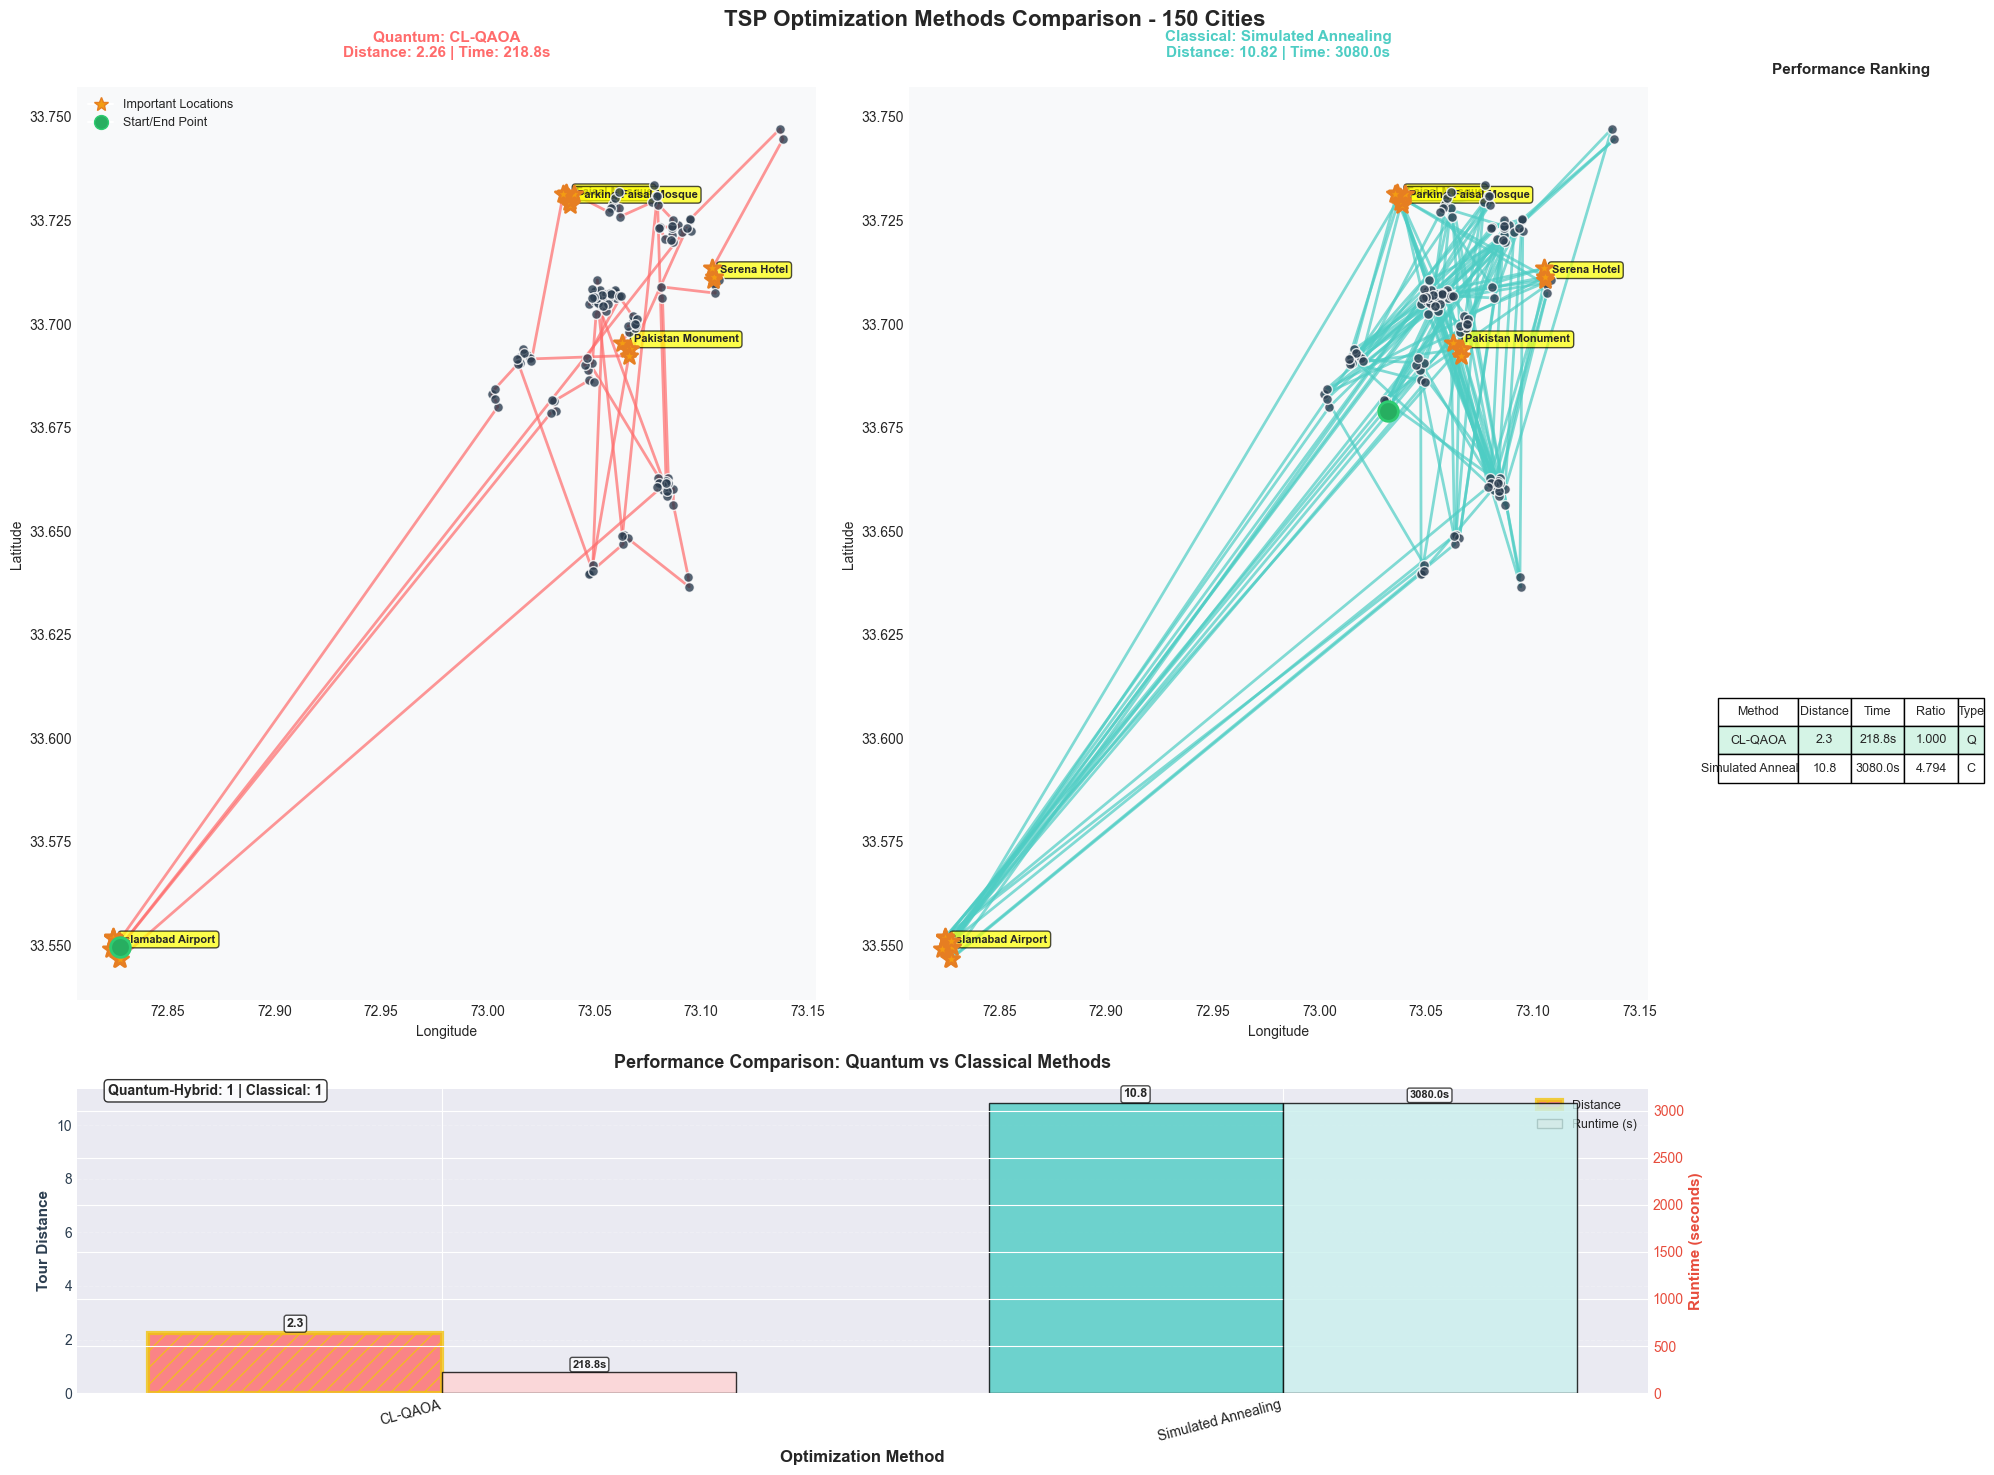


Visualization complete!
The visualization includes:
   - Individual tour plots for each method
   - Performance comparison chart
   - Ranking table
   - Quantum vs Classical analysis
   - High-quality exports in multiple formats
   - Complete data files for later analysis


In [56]:
# ============================================
# CELL 6: VISUALIZATION - TOUR COMPARISON
# ============================================

def convert_to_serializable(obj):
    """Convert numpy arrays and other non-serializable objects to JSON-serializable format"""
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    elif isinstance(obj, np.integer):
        return int(obj)
    elif isinstance(obj, np.floating):
        return float(obj)
    elif hasattr(obj, 'tolist'):  # For any object with tolist method
        return obj.tolist()
    elif isinstance(obj, dict):
        return {key: convert_to_serializable(value) for key, value in obj.items()}
    elif isinstance(obj, list):
        return [convert_to_serializable(item) for item in obj]
    elif isinstance(obj, tuple):
        return tuple(convert_to_serializable(item) for item in obj)
    else:
        return obj

def plot_tour_comparison(coordinates, methods_results, location_names, optimal_tour=None, optimal_cost=None, figsize=(20, 15)):
    """Plot tours from all methods side by side with enhanced analysis"""
    
    # Filter out methods with errors
    valid_methods = {m: d for m, d in methods_results.items() 
                    if not d.get('error', False) and len(d.get('tour', [])) > 0}
    
    if not valid_methods:
        print("No valid methods to visualize")
        return None, None  # Return None for both figure and data
    
    n_methods = len(valid_methods)
    methods = list(valid_methods.keys())
    
    # Create figure with subplots
    fig = plt.figure(figsize=figsize)
    
    # Create grid layout
    if n_methods <= 3:
        n_cols = n_methods
        n_rows = 2
        gs = GridSpec(2, n_cols + 1, height_ratios=[3, 1], width_ratios=[1]*n_cols + [0.3])
    else:
        n_cols = min(n_methods, 4)
        n_rows = (n_methods + 1) // n_cols + 1
        gs = GridSpec(n_rows, n_cols + 1, height_ratios=[2]*n_rows, width_ratios=[1]*n_cols + [0.3])
    
    # Method type colors
    method_colors = {
        'CL-QAOA': '#FF6B6B',  # Quantum red
        'Quantum': '#FF6B6B',
        'Simulated Annealing': '#4ECDC4',  # Classical blue
        'Classical': '#4ECDC4',
        'Ant Colony': '#45B7D1',  # Another classical blue
        'Other': '#96CEB4'  # Neutral green
    }
    
    # Data to save for later analysis
    visualization_data = {
        'tour_data': {},
        'method_stats': {},
        'coordinates': coordinates.tolist(),  # Always convert to list
        'location_names': location_names if location_names is not None else []
    }
    
    # Plot tours for each method
    for i, method in enumerate(methods):
        if i >= n_cols * (n_rows - 1):  # Check if we have space
            break
            
        row = i // n_cols
        col = i % n_cols
        
        ax = fig.add_subplot(gs[row, col])
        data = valid_methods[method]
        tour = data['tour']
        cost = data['actual_cost']
        runtime = data['runtime']
        
        # Get method type for coloring
        method_type = 'Other'
        for key in method_colors:
            if key in method:
                method_type = key
                break
        
        # Plot the tour
        if len(tour) > 0:
            tour_coords = coordinates[tour]
            tour_coords = np.vstack([tour_coords, tour_coords[0]])  # Close the loop
            
            # Plot tour path with gradient color
            for j in range(len(tour_coords) - 1):
                ax.plot(tour_coords[j:j+2, 0], tour_coords[j:j+2, 1], 
                       color=method_colors[method_type], 
                       alpha=0.7, 
                       linewidth=2,
                       solid_capstyle='round')
        
        # Plot cities
        scatter = ax.scatter(coordinates[:, 0], coordinates[:, 1], 
                           c='#2C3E50', s=50, alpha=0.8, 
                           edgecolors='white', linewidth=1, zorder=5)
        
        # Highlight important locations
        important_keywords = ['Mosque', 'Monument', 'Airport', 'Hotel', 'Station', 'Center']
        important_indices = []
        important_names = []
        
        if location_names is not None:
            for idx, name in enumerate(location_names):
                for keyword in important_keywords:
                    if keyword.lower() in str(name).lower():
                        important_indices.append(idx)
                        important_names.append(str(name))
                        break
        
        if important_indices:
            ax.scatter(coordinates[important_indices, 0], coordinates[important_indices, 1],
                      c='#F39C12', s=150, marker='*', 
                      edgecolors='#E67E22', linewidth=2, zorder=6,
                      label='Important Locations')
        
        # Add start/end markers
        if len(tour) > 0:
            # Starting point
            ax.scatter(coordinates[tour[0], 0], coordinates[tour[0], 1],
                      c='#27AE60', s=200, marker='o', 
                      edgecolors='#2ECC71', linewidth=2, zorder=7,
                      label='Start/End')
            
            # Add city labels for important locations
            for idx in important_indices[:5]:  # Limit to 5 labels for clarity
                if idx < len(location_names):
                    ax.annotate(str(location_names[idx]), 
                              (coordinates[idx, 0], coordinates[idx, 1]),
                              xytext=(5, 5), textcoords='offset points',
                              fontsize=8, fontweight='bold',
                              bbox=dict(boxstyle="round,pad=0.3", 
                                      facecolor="yellow", alpha=0.7))
        
        # Set titles and labels
        ax.set_xlabel('Longitude', fontsize=10)
        ax.set_ylabel('Latitude', fontsize=10)
        
        # Enhanced title with performance metrics
        title_color = method_colors[method_type]
        method_prefix = "Quantum: " if 'CL-QAOA' in method or 'Quantum' in method else "Classical: "
        
        title_text = f'{method_prefix}{method}\n'
        title_text += f'Distance: {cost:.2f} | Time: {runtime:.1f}s\n'
        
        # Add comparison to optimal/best if available
        if optimal_cost and cost > 0:
            optimal_ratio = cost / optimal_cost
            title_text += f'Optimal Ratio: {optimal_ratio:.3f}'
            if optimal_ratio < 1.1:
                title_text += ' (Excellent)'
            elif optimal_ratio > 1.5:
                title_text += ' (Poor)'
        
        ax.set_title(title_text, fontsize=11, fontweight='bold', 
                    color=title_color, pad=10)
        
        ax.grid(True, alpha=0.2, linestyle='--', linewidth=0.5)
        ax.set_facecolor('#F8F9FA')
        
        # Save tour data for later analysis
        visualization_data['tour_data'][method] = {
            'tour': tour.tolist() if hasattr(tour, 'tolist') else list(tour),
            'cost': float(cost),
            'runtime': float(runtime),
            'method_type': 'quantum' if 'CL-QAOA' in method else 'classical',
            'coordinates': tour_coords.tolist()  # Always convert to list
        }
        
        # Add legend for first subplot only
        if i == 0 and (important_indices or len(tour) > 0):
            handles = []
            labels = []
            
            if important_indices:
                handles.append(plt.Line2D([0], [0], marker='*', color='w', 
                                        markerfacecolor='#F39C12', markersize=10,
                                        markeredgecolor='#E67E22', markeredgewidth=1))
                labels.append('Important Locations')
            
            if len(tour) > 0:
                handles.append(plt.Line2D([0], [0], marker='o', color='w', 
                                        markerfacecolor='#27AE60', markersize=10,
                                        markeredgecolor='#2ECC71', markeredgewidth=1))
                labels.append('Start/End Point')
            
            ax.legend(handles, labels, loc='upper left', fontsize=9,
                     framealpha=0.9, fancybox=True)
    
    # Plot comparison bar chart in the bottom row
    ax_compare = fig.add_subplot(gs[-1, :-1])
    
    methods_list = list(valid_methods.keys())
    costs = [valid_methods[m]['actual_cost'] for m in methods_list]
    runtimes = [valid_methods[m]['runtime'] for m in methods_list]
    
    # Get method colors for bars
    bar_colors = [method_colors.get(next((k for k in method_colors if k in m), 'Other'), '#96CEB4') 
                 for m in methods_list]
    
    x = np.arange(len(methods_list))
    width = 0.35
    
    # Create grouped bars
    bars1 = ax_compare.bar(x - width/2, costs, width, 
                          label='Distance', 
                          color=bar_colors,
                          edgecolor='black', linewidth=1, alpha=0.8)
    
    ax_compare.set_xlabel('Optimization Method', fontsize=12, fontweight='bold')
    ax_compare.set_ylabel('Tour Distance', color='#2C3E50', fontsize=11, fontweight='bold')
    ax_compare.tick_params(axis='y', labelcolor='#2C3E50')
    
    # Add runtime on secondary axis
    ax_compare2 = ax_compare.twinx()
    bars2 = ax_compare2.bar(x + width/2, runtimes, width, 
                           label='Runtime (s)', 
                           color=[lighten_color(c, 0.3) for c in bar_colors],
                           edgecolor='black', linewidth=1, alpha=0.8)
    
    ax_compare2.set_ylabel('Runtime (seconds)', color='#E74C3C', fontsize=11, fontweight='bold')
    ax_compare2.tick_params(axis='y', labelcolor='#E74C3C')
    
    ax_compare.set_xticks(x)
    ax_compare.set_xticklabels(methods_list, rotation=15, ha='right', fontsize=10)
    
    # Add optimal cost line if available
    if optimal_cost:
        ax_compare.axhline(y=optimal_cost, color='#27AE60', linestyle='--', 
                          linewidth=2, alpha=0.7, label='Optimal Solution')
        ax_compare.text(len(methods_list) - 0.5, optimal_cost, 
                       f'Optimal: {optimal_cost:.2f}', 
                       va='bottom', ha='right', fontsize=9,
                       bbox=dict(boxstyle="round,pad=0.3", facecolor="#27AE60", alpha=0.2))
    
    # Highlight best method
    best_idx = np.argmin(costs)
    bars1[best_idx].set_edgecolor('#F1C40F')
    bars1[best_idx].set_linewidth(3)
    bars1[best_idx].set_hatch('//')
    
    # Add value labels on bars
    for bar in bars1:
        height = bar.get_height()
        ax_compare.text(bar.get_x() + bar.get_width()/2., height + max(costs)*0.01,
                       f'{height:.1f}', 
                       ha='center', va='bottom', 
                       fontsize=9, fontweight='bold',
                       bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.7))
    
    for bar in bars2:
        height = bar.get_height()
        ax_compare2.text(bar.get_x() + bar.get_width()/2., height + max(runtimes)*0.01,
                        f'{height:.1f}s', 
                        ha='center', va='bottom', 
                        fontsize=8, fontweight='bold',
                        bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.7))
    
    # Add quantum vs classical grouping
    quantum_count = sum(1 for m in methods_list if 'CL-QAOA' in m or 'Quantum' in m)
    classical_count = len(methods_list) - quantum_count
    
    ax_compare.text(0.02, 0.98, 
                   f'Quantum-Hybrid: {quantum_count} | Classical: {classical_count}',
                   transform=ax_compare.transAxes,
                   fontsize=10, fontweight='bold',
                   bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
    
    ax_compare.set_title('Performance Comparison: Quantum vs Classical Methods', 
                        fontsize=13, fontweight='bold', pad=15)
    ax_compare.grid(True, alpha=0.2, linestyle='--', axis='y')
    ax_compare.set_axisbelow(True)
    
    # Add legends
    lines1, labels1 = ax_compare.get_legend_handles_labels()
    lines2, labels2 = ax_compare2.get_legend_handles_labels()
    ax_compare.legend(lines1 + lines2, labels1 + labels2, 
                     loc='upper right', fontsize=9,
                     framealpha=0.9, fancybox=True)
    
    # Save comparison data
    visualization_data['comparison_data'] = {
        'methods': methods_list,
        'costs': [float(c) for c in costs],
        'runtimes': [float(r) for r in runtimes],
        'best_method': methods_list[best_idx],
        'best_cost': float(min(costs)),
        'quantum_count': quantum_count,
        'classical_count': classical_count
    }
    
    # Add performance summary table on the right
    if n_cols * (n_rows - 1) > len(methods):
        ax_table = fig.add_subplot(gs[:-1, -1])
    else:
        ax_table = fig.add_subplot(gs[:, -1])
    
    ax_table.axis('tight')
    ax_table.axis('off')
    
    # Prepare table data
    table_data = []
    for i, method in enumerate(methods_list):
        data = valid_methods[method]
        ratio = data['actual_cost'] / min(costs) if min(costs) > 0 else 1
        table_data.append([
            method,
            f"{data['actual_cost']:.1f}",
            f"{data['runtime']:.1f}s",
            f"{ratio:.3f}",
            "Q" if 'CL-QAOA' in method or 'Quantum' in method else "C"
        ])
    
    # Sort by distance
    table_data.sort(key=lambda x: float(x[1]))
    
    table = ax_table.table(cellText=table_data,
                          colLabels=['Method', 'Distance', 'Time', 'Ratio', 'Type'],
                          cellLoc='center',
                          loc='center',
                          colWidths=[0.3, 0.2, 0.2, 0.2, 0.1])
    
    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1.2, 1.5)
    
    # Color the best row
    for i in range(len(table_data)):
        if i == 0:  # Best performing
            for j in range(len(table_data[i])):  # Fixed: removed +1
                table[(i+1, j)].set_facecolor('#D5F4E6')  # Light green
    
    ax_table.set_title('Performance Ranking', fontsize=11, fontweight='bold', pad=10)
    
    plt.suptitle(f'TSP Optimization Methods Comparison - {len(coordinates)} Cities', 
                fontsize=16, fontweight='bold', y=0.98)
    
    plt.tight_layout()
    
    # ============================================
    # SAVE VISUALIZATION AND DATA
    # ============================================
    timestamp = time.strftime("%Y%m%d_%H%M%S")
    
    # 1. Save high-quality figure
    png_filename = f'tour_comparison_{len(coordinates)}cities_{timestamp}.png'
    plt.savefig(png_filename, dpi=300, bbox_inches='tight', facecolor='white')
    
    # 2. Save as PDF for publication quality
    pdf_filename = f'tour_comparison_{len(coordinates)}cities_{timestamp}.pdf'
    plt.savefig(pdf_filename, bbox_inches='tight', facecolor='white')
    
    # 3. Save as SVG for vector editing
    svg_filename = f'tour_comparison_{len(coordinates)}cities_{timestamp}.svg'
    plt.savefig(svg_filename, bbox_inches='tight', facecolor='white')
    
    # 4. Save visualization data as JSON
    import json
    data_filename = f'tour_visualization_data_{len(coordinates)}cities_{timestamp}.json'
    
    # Add metadata to visualization data
    visualization_data['metadata'] = {
        'filename': png_filename,
        'timestamp': timestamp,
        'n_cities': len(coordinates),
        'n_methods': len(methods_list),
        'best_method': methods_list[best_idx],
        'best_cost': float(min(costs)),
        'figure_size': list(figsize),  # Convert tuple to list
        'color_scheme': method_colors
    }
    
    # Convert to JSON serializable format
    serializable_data = convert_to_serializable(visualization_data)
    
    with open(data_filename, 'w') as f:
        json.dump(serializable_data, f, indent=2)
    
    # 5. Save visualization data as pickle for full object serialization
    import pickle
    pickle_filename = f'tour_visualization_complete_{len(coordinates)}cities_{timestamp}.pkl'
    
    # For pickle, we need to make sure methods_results is clean
    clean_methods_results = {}
    for method, data in valid_methods.items():
        clean_methods_results[method] = {}
        for key, value in data.items():
            if key == 'tour':
                clean_methods_results[method][key] = value.tolist() if hasattr(value, 'tolist') else list(value)
            elif key in ['actual_cost', 'runtime', 'qubo_cost']:
                clean_methods_results[method][key] = float(value)
            else:
                clean_methods_results[method][key] = value
    
    complete_viz_data = {
        'visualization_data': serializable_data,  # Use serializable version
        'figure_object': fig,
        'methods_results': clean_methods_results,
        'coordinates': coordinates.tolist(),
        'location_names': location_names if location_names is not None else [],
        'timestamp': timestamp
    }
    
    with open(pickle_filename, 'wb') as f:
        pickle.dump(complete_viz_data, f)
    
    # 6. Save tour coordinates for each method as CSV
    import pandas as pd
    for method, data in valid_methods.items():
        if 'tour' in data and len(data['tour']) > 0:
            tour_list = data['tour'].tolist() if hasattr(data['tour'], 'tolist') else list(data['tour'])
            tour_df = pd.DataFrame({
                'Step': list(range(len(tour_list))) + [len(tour_list)],
                'City_Index': tour_list + [tour_list[0]],
                'Longitude': coordinates[tour_list + [tour_list[0]], 0],
                'Latitude': coordinates[tour_list + [tour_list[0]], 1]
            })
            # Clean method name for filename
            clean_method_name = method.replace(' ', '_').replace('/', '_')
            tour_csv = f'tour_path_{clean_method_name}_{len(coordinates)}cities_{timestamp}.csv'
            tour_df.to_csv(tour_csv, index=False)
    
    print(f"Visualization saved as:")
    print(f"   PNG: {png_filename}")
    print(f"   PDF: {pdf_filename}")
    print(f"   SVG: {svg_filename}")
    print(f"   Data JSON: {data_filename}")
    print(f"   Complete data (pickle): {pickle_filename}")
    
    # Create a summary file
    summary_filename = f'visualization_summary_{timestamp}.txt'
    with open(summary_filename, 'w', encoding='utf-8') as f:
        f.write("="*80 + "\n")
        f.write("VISUALIZATION SUMMARY REPORT\n")
        f.write("="*80 + "\n\n")
        f.write(f"Generated: {timestamp}\n")
        f.write(f"Problem: TSP with {len(coordinates)} cities\n")
        f.write(f"Methods visualized: {len(methods_list)}\n")
        f.write(f"Best method: {methods_list[best_idx]} ({min(costs):.2f})\n\n")
        f.write("Files generated:\n")
        f.write(f"1. {png_filename} (PNG image)\n")
        f.write(f"2. {pdf_filename} (PDF document)\n")
        f.write(f"3. {svg_filename} (SVG vector)\n")
        f.write(f"4. {data_filename} (JSON data)\n")
        f.write(f"5. {pickle_filename} (Complete pickle)\n")
        f.write(f"6. Tour CSV files for each method\n")
    
    print(f"   Summary report: {summary_filename}")
    
    plt.show()
    
    return fig, visualization_data

# Helper function to lighten colors
def lighten_color(color, amount=0.5):
    """
    Lightens the given color by multiplying (1-luminosity) by the given amount.
    Input can be matplotlib color string, hex string, or RGB tuple.
    """
    import matplotlib.colors as mc
    import colorsys
    
    try:
        c = mc.cnames[color]
    except:
        c = color
    
    c = colorsys.rgb_to_hls(*mc.to_rgb(c))
    return colorsys.hls_to_rgb(c[0], 1 - amount * (1 - c[1]), c[2])

# Generate enhanced comparison plot
print("\n" + "="*80)
print("GENERATING VISUALIZATION")
print("="*80)

# Get optimal tour if available
optimal_tour_param = optimal_tour if 'optimal_tour' in locals() else None
optimal_cost_param = optimal_cost if 'optimal_cost' in locals() else None

print(f"Visualizing {len(methods_results)} methods for {len(coordinates)} cities")
print(f"Quantum methods: {sum(1 for m in methods_results if 'CL-QAOA' in m)}")
print(f"Classical methods: {sum(1 for m in methods_results if 'CL-QAOA' not in m)}")

if len(methods_results) > 0:
    result = plot_tour_comparison(
        coordinates, 
        methods_results, 
        location_names,
        optimal_tour=optimal_tour_param,
        optimal_cost=optimal_cost_param
    )
    
    if result and result[0] is not None:
        fig_tours, viz_data = result
        print("\nVisualization complete!")
        print("The visualization includes:")
        print("   - Individual tour plots for each method")
        print("   - Performance comparison chart")
        print("   - Ranking table")
        print("   - Quantum vs Classical analysis")
        print("   - High-quality exports in multiple formats")
        print("   - Complete data files for later analysis")
    else:
        print("\nVisualization failed or no valid methods to visualize")
else:
    print("No methods to visualize")

APPROXIMATION RATIO ANALYSIS

Simulated Annealing:
  Actual Distance: 10.89
  AR_min: 0.0000
  Normalized to Best: 1.0000

🏆 Best Method: Simulated Annealing (10.89)
⚠️ Worst Method: Simulated Annealing (10.89)
📈 Improvement: 0.0%



GENERATING APPROXIMATION RATIO VISUALIZATIONS

 Approximation ratio plots saved in directory: ar_plots_20260205_224518/
   Composite figure: ar_plots_20260205_224518/approximation_analysis_150cities_20260205_224518.png
   Individual plots: 4 plots saved in PNG and PDF formats
   Data files: JSON and pickle formats saved
   Configuration: Plot settings saved for reproducibility
   README: ar_plots_20260205_224518/README_20260205_224518.txt


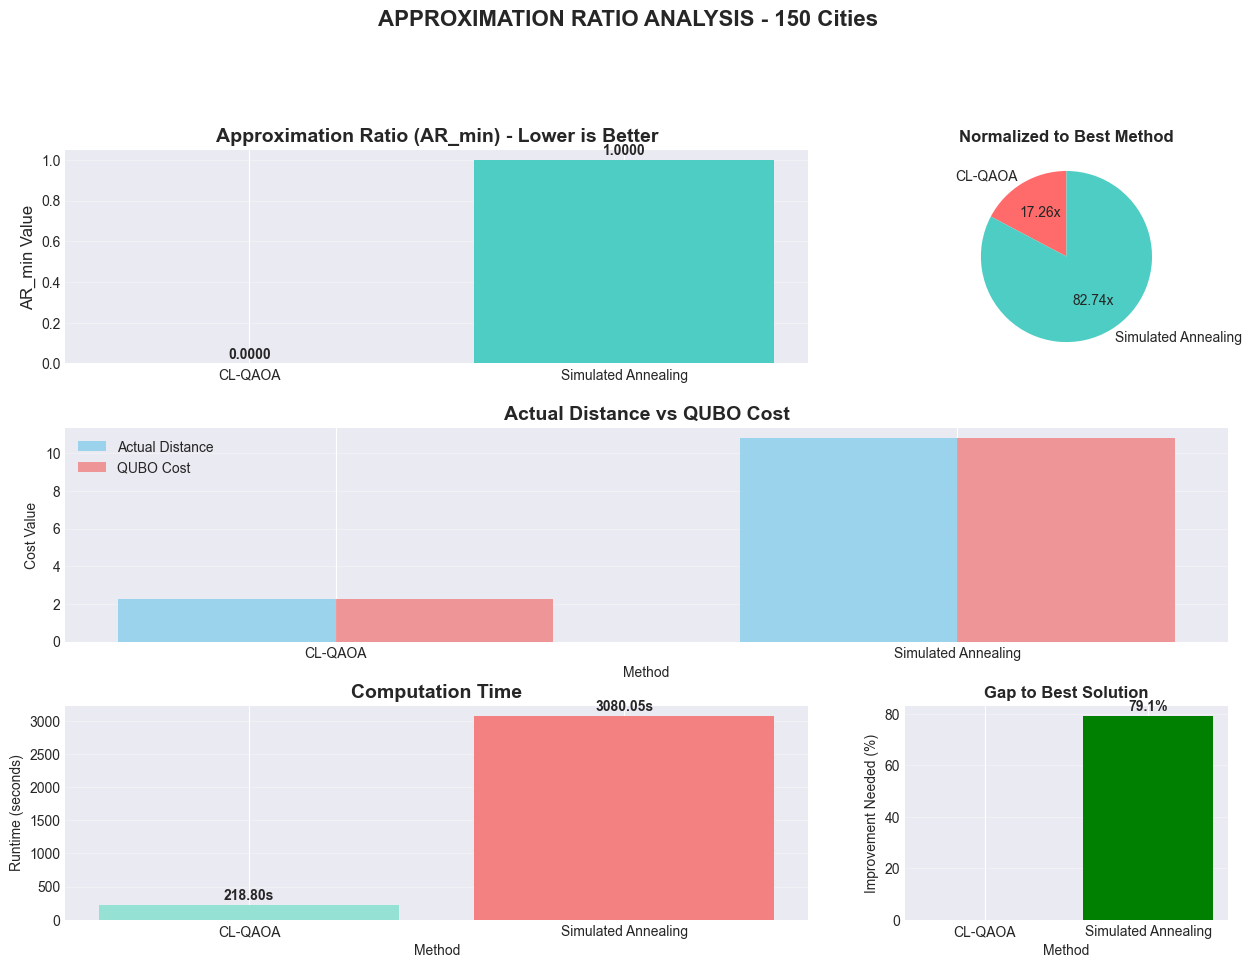


 Approximation ratio analysis complete!
   Methods analyzed: 2
   Best method: CL-QAOA
   Best cost: 2.26
   All plots and data saved for later use


In [58]:
# ============================================
# CELL 7: VISUALIZATION - APPROXIMATION RATIOS
# ============================================

def plot_approximation_ratios(ar_results, methods_results, n_cities, figsize=(15, 10)):
    """Create comprehensive visualization of approximation ratios"""
    
    # Get timestamp for filenames
    timestamp = time.strftime("%Y%m%d_%H%M%S")
    
    fig = plt.figure(figsize=figsize)
    gs = GridSpec(3, 3, hspace=0.3, wspace=0.3)
    
    # 1. AR_min values (Equation 28-29 from paper)
    ax1 = fig.add_subplot(gs[0, :2])
    methods = list(ar_results.keys())
    ar_values = [ar_results[m]['AR_min'] for m in methods if ar_results[m]['AR_min'] is not None]
    
    bars = ax1.bar(methods, ar_values, color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
    ax1.set_ylabel('AR_min Value', fontsize=12)
    ax1.set_title('Approximation Ratio (AR_min) - Lower is Better', fontsize=14, fontweight='bold')
    ax1.grid(True, alpha=0.3, axis='y')
    
    # Add value labels
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{height:.4f}', ha='center', va='bottom', fontweight='bold')
    
    # 2. Normalized performance
    ax2 = fig.add_subplot(gs[0, 2])
    normalized_values = [ar_results[m]['normalized_to_best'] for m in methods 
                        if ar_results[m]['normalized_to_best'] is not None]
    
    wedges, texts, autotexts = ax2.pie(normalized_values, labels=methods, autopct='%1.2fx',
                                       colors=['#FF6B6B', '#4ECDC4', '#45B7D1'],
                                       startangle=90)
    ax2.set_title('Normalized to Best Method', fontsize=12, fontweight='bold')
    
    # 3. Cost comparison with breakdown
    ax3 = fig.add_subplot(gs[1, :])
    methods_list = list(methods_results.keys())
    costs = [methods_results[m]['actual_cost'] for m in methods_list]
    qubo_costs = [methods_results[m]['qubo_cost'] for m in methods_list]
    
    x = np.arange(len(methods_list))
    width = 0.35
    
    bars1 = ax3.bar(x - width/2, costs, width, label='Actual Distance', color='skyblue', alpha=0.8)
    bars2 = ax3.bar(x + width/2, qubo_costs, width, label='QUBO Cost', color='lightcoral', alpha=0.8)
    
    ax3.set_xlabel('Method')
    ax3.set_ylabel('Cost Value')
    ax3.set_title('Actual Distance vs QUBO Cost', fontsize=14, fontweight='bold')
    ax3.set_xticks(x)
    ax3.set_xticklabels(methods_list, rotation=0)
    ax3.legend()
    ax3.grid(True, alpha=0.3, axis='y')
    
    # 4. Runtime comparison
    ax4 = fig.add_subplot(gs[2, :2])
    runtimes = [methods_results[m]['runtime'] for m in methods_list]
    
    bars_runtime = ax4.bar(methods_list, runtimes, color=['#95E1D3', '#F38181', '#FCE38A'])
    ax4.set_xlabel('Method')
    ax4.set_ylabel('Runtime (seconds)')
    ax4.set_title('Computation Time', fontsize=14, fontweight='bold')
    ax4.grid(True, alpha=0.3, axis='y')
    
    # Add runtime labels
    for bar in bars_runtime:
        height = bar.get_height()
        ax4.text(bar.get_x() + bar.get_width()/2., height + max(runtimes)*0.01,
                f'{height:.2f}s', ha='center', va='bottom', fontweight='bold')
    
    # 5. Improvement percentages
    ax5 = fig.add_subplot(gs[2, 2])
    best_cost = min(costs)
    improvements = [((cost - best_cost) / cost * 100) if cost > best_cost else 0 
                   for cost in costs]
    
    colors_improvement = ['gray' if imp == 0 else 'green' for imp in improvements]
    bars_improvement = ax5.bar(methods_list, improvements, color=colors_improvement)
    ax5.set_xlabel('Method')
    ax5.set_ylabel('Improvement Needed (%)')
    ax5.set_title('Gap to Best Solution', fontsize=12, fontweight='bold')
    ax5.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
    ax5.grid(True, alpha=0.3, axis='y')
    
    for bar, imp in zip(bars_improvement, improvements):
        if imp > 0:
            height = bar.get_height()
            ax5.text(bar.get_x() + bar.get_width()/2., height + 1,
                    f'{imp:.1f}%', ha='center', va='bottom', fontweight='bold')
    
    plt.suptitle(f'APPROXIMATION RATIO ANALYSIS - {n_cities} Cities', 
                fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    
    # ============================================
    # SAVE PLOTS IN MULTIPLE FORMATS
    # ============================================
    import os
    
    # Create plots directory if it doesn't exist
    plots_dir = f'ar_plots_{timestamp}'
    os.makedirs(plots_dir, exist_ok=True)
    
    # Save main composite figure
    composite_filenames = {
        'png': f'{plots_dir}/approximation_analysis_{n_cities}cities_{timestamp}.png',
        'pdf': f'{plots_dir}/approximation_analysis_{n_cities}cities_{timestamp}.pdf',
        'svg': f'{plots_dir}/approximation_analysis_{n_cities}cities_{timestamp}.svg'
    }
    
    for fmt, filename in composite_filenames.items():
        plt.savefig(filename, dpi=300, bbox_inches='tight', facecolor='white')
    
    # ============================================
    # SAVE INDIVIDUAL SUBPLOTS
    # ============================================
    
    # 1. Save AR_min plot individually
    fig_ar_min, ax_ar_min = plt.subplots(figsize=(8, 6))
    bars_individual = ax_ar_min.bar(methods, ar_values, color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
    ax_ar_min.set_ylabel('AR_min Value', fontsize=12)
    ax_ar_min.set_title(f'Approximation Ratio (AR_min) - {n_cities} Cities', 
                       fontsize=14, fontweight='bold')
    ax_ar_min.grid(True, alpha=0.3, axis='y')
    
    for bar in bars_individual:
        height = bar.get_height()
        ax_ar_min.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                      f'{height:.4f}', ha='center', va='bottom', fontweight='bold')
    
    fig_ar_min.savefig(f'{plots_dir}/ar_min_plot_{n_cities}cities_{timestamp}.png', 
                      dpi=300, bbox_inches='tight')
    fig_ar_min.savefig(f'{plots_dir}/ar_min_plot_{n_cities}cities_{timestamp}.pdf', 
                      bbox_inches='tight')
    plt.close(fig_ar_min)
    
    # 2. Save cost comparison plot individually
    fig_cost, ax_cost = plt.subplots(figsize=(10, 6))
    bars_cost1 = ax_cost.bar(x - width/2, costs, width, label='Actual Distance', 
                            color='skyblue', alpha=0.8)
    bars_cost2 = ax_cost.bar(x + width/2, qubo_costs, width, label='QUBO Cost', 
                            color='lightcoral', alpha=0.8)
    
    ax_cost.set_xlabel('Method')
    ax_cost.set_ylabel('Cost Value')
    ax_cost.set_title(f'Cost Comparison - {n_cities} Cities', fontsize=14, fontweight='bold')
    ax_cost.set_xticks(x)
    ax_cost.set_xticklabels(methods_list, rotation=0)
    ax_cost.legend()
    ax_cost.grid(True, alpha=0.3, axis='y')
    
    fig_cost.savefig(f'{plots_dir}/cost_comparison_{n_cities}cities_{timestamp}.png', 
                    dpi=300, bbox_inches='tight')
    fig_cost.savefig(f'{plots_dir}/cost_comparison_{n_cities}cities_{timestamp}.pdf', 
                    bbox_inches='tight')
    plt.close(fig_cost)
    
    # 3. Save runtime comparison plot individually
    fig_runtime, ax_runtime = plt.subplots(figsize=(8, 6))
    bars_rt = ax_runtime.bar(methods_list, runtimes, color=['#95E1D3', '#F38181', '#FCE38A'])
    ax_runtime.set_xlabel('Method')
    ax_runtime.set_ylabel('Runtime (seconds)')
    ax_runtime.set_title(f'Computation Time - {n_cities} Cities', fontsize=14, fontweight='bold')
    ax_runtime.grid(True, alpha=0.3, axis='y')
    
    for bar in bars_rt:
        height = bar.get_height()
        ax_runtime.text(bar.get_x() + bar.get_width()/2., height + max(runtimes)*0.01,
                       f'{height:.2f}s', ha='center', va='bottom', fontweight='bold')
    
    fig_runtime.savefig(f'{plots_dir}/runtime_comparison_{n_cities}cities_{timestamp}.png', 
                       dpi=300, bbox_inches='tight')
    fig_runtime.savefig(f'{plots_dir}/runtime_comparison_{n_cities}cities_{timestamp}.pdf', 
                       bbox_inches='tight')
    plt.close(fig_runtime)
    
    # 4. Save improvement percentages plot individually
    fig_improve, ax_improve = plt.subplots(figsize=(8, 6))
    bars_imp = ax_improve.bar(methods_list, improvements, color=colors_improvement)
    ax_improve.set_xlabel('Method')
    ax_improve.set_ylabel('Improvement Needed (%)')
    ax_improve.set_title(f'Performance Gap - {n_cities} Cities', fontsize=14, fontweight='bold')
    ax_improve.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
    ax_improve.grid(True, alpha=0.3, axis='y')
    
    for bar, imp in zip(bars_imp, improvements):
        if imp > 0:
            height = bar.get_height()
            ax_improve.text(bar.get_x() + bar.get_width()/2., height + 1,
                          f'{imp:.1f}%', ha='center', va='bottom', fontweight='bold')
    
    fig_improve.savefig(f'{plots_dir}/improvement_gap_{n_cities}cities_{timestamp}.png', 
                       dpi=300, bbox_inches='tight')
    fig_improve.savefig(f'{plots_dir}/improvement_gap_{n_cities}cities_{timestamp}.pdf', 
                       bbox_inches='tight')
    plt.close(fig_improve)
    
    # ============================================
    # SAVE PLOT DATA FOR LATER USE
    # ============================================
    import json
    import pickle
    
    # Save plot data as JSON
    plot_data = {
        'timestamp': timestamp,
        'n_cities': n_cities,
        'methods': methods_list,
        'ar_values': ar_values,
        'normalized_values': normalized_values,
        'costs': costs,
        'qubo_costs': qubo_costs,
        'runtimes': runtimes,
        'improvements': improvements,
        'best_cost': best_cost,
        'best_method': methods_list[costs.index(best_cost)] if best_cost in costs else None,
        'ar_results_summary': {
            method: {
                'AR_min': ar_results[method].get('AR_min'),
                'normalized_to_best': ar_results[method].get('normalized_to_best'),
                'actual_cost': methods_results[method].get('actual_cost'),
                'runtime': methods_results[method].get('runtime')
            }
            for method in methods_list
        }
    }
    
    json_filename = f'{plots_dir}/ar_plot_data_{n_cities}cities_{timestamp}.json'
    with open(json_filename, 'w') as f:
        json.dump(plot_data, f, indent=2)
    
    # Save plot data as pickle (includes figure object)
    pickle_data = {
        'figure': fig,
        'plot_data': plot_data,
        'ar_results': ar_results,
        'methods_results': methods_results,
        'timestamp': timestamp
    }
    
    pickle_filename = f'{plots_dir}/ar_plot_complete_{n_cities}cities_{timestamp}.pkl'
    with open(pickle_filename, 'wb') as f:
        pickle.dump(pickle_data, f)
    
    # Save configuration for replotting
    config_data = {
        'plot_config': {
            'figure_size': figsize,
            'color_schemes': {
                'ar_min': ['#FF6B6B', '#4ECDC4', '#45B7D1'],
                'cost_comparison': ['skyblue', 'lightcoral'],
                'runtime': ['#95E1D3', '#F38181', '#FCE38A']
            },
            'grid_settings': {
                'alpha': 0.3,
                'axis': 'y'
            }
        },
        'data_sources': {
            'ar_results': list(ar_results.keys()),
            'methods_results': list(methods_results.keys())
        }
    }
    
    config_filename = f'{plots_dir}/plot_config_{timestamp}.json'
    with open(config_filename, 'w') as f:
        json.dump(config_data, f, indent=2)
    
    # Create README file for the plot directory
    readme_content = f"""Approximation Ratio Analysis Plots - {timestamp}
================================================

Problem: TSP with {n_cities} cities
Methods analyzed: {len(methods_list)}
Date generated: {timestamp}

FILES IN THIS DIRECTORY:
========================

1. Composite Figures:
   - approximation_analysis_{{n_cities}}cities_{{timestamp}}.png (main composite)
   - approximation_analysis_{{n_cities}}cities_{{timestamp}}.pdf
   - approximation_analysis_{{n_cities}}cities_{{timestamp}}.svg

2. Individual Plots:
   - ar_min_plot_{{n_cities}}cities_{{timestamp}}.[png/pdf] - AR_min values
   - cost_comparison_{{n_cities}}cities_{{timestamp}}.[png/pdf] - Cost comparison
   - runtime_comparison_{{n_cities}}cities_{{timestamp}}.[png/pdf] - Runtime analysis
   - improvement_gap_{{n_cities}}cities_{{timestamp}}.[png/pdf] - Improvement percentages

3. Data Files:
   - ar_plot_data_{{n_cities}}cities_{{timestamp}}.json - Plot data in JSON
   - ar_plot_complete_{{n_cities}}cities_{{timestamp}}.pkl - Complete data (pickle)
   - plot_config_{{timestamp}}.json - Plot configuration

4. This README file

DATA SUMMARY:
=============
Methods: {', '.join(methods_list)}
Best method: {plot_data['best_method']}
Best cost: {best_cost:.2f}
AR_min range: {min(ar_values):.4f} - {max(ar_values):.4f}
Runtime range: {min(runtimes):.2f}s - {max(runtimes):.2f}s

USE CASES:
==========
- PNG files: For presentations and reports
- PDF files: For publication-quality documents
- SVG files: For vector editing
- JSON files: For data analysis in other tools
- Pickle files: For reloading complete Python objects

GENERATED BY: TSP Quantum-Classical Comparison Analysis
"""
    
    readme_filename = f'{plots_dir}/README_{timestamp}.txt'
    with open(readme_filename, 'w') as f:
        f.write(readme_content)
    
    # Display summary
    print(f"\n Approximation ratio plots saved in directory: {plots_dir}/")
    print(f"   Composite figure: {composite_filenames['png']}")
    print(f"   Individual plots: 4 plots saved in PNG and PDF formats")
    print(f"   Data files: JSON and pickle formats saved")
    print(f"   Configuration: Plot settings saved for reproducibility")
    print(f"   README: {readme_filename}")
    
    plt.show()
    
    return fig, plot_data

# Generate approximation ratio analysis
print("\n" + "="*80)
print("GENERATING APPROXIMATION RATIO VISUALIZATIONS")
print("="*80)

if 'ar_results' in locals() and ar_results and 'methods_results' in locals() and methods_results:
    # Get number of cities from coordinates
    n_cities = len(coordinates) if 'coordinates' in locals() else 'unknown'
    
    fig_ar, ar_plot_data = plot_approximation_ratios(ar_results, methods_results, n_cities)
    
    if fig_ar:
        print(f"\n Approximation ratio analysis complete!")
        print(f"   Methods analyzed: {len(ar_results)}")
        print(f"   Best method: {ar_plot_data['best_method']}")
        print(f"   Best cost: {ar_plot_data['best_cost']:.2f}")
        print(f"   All plots and data saved for later use")
else:
    print(" No approximation ratio data available for visualization")
    print("   Make sure to run the approximation ratio calculation first")

CONSTRAINT SATISFACTION ANALYSIS

CL-QAOA:
  Constraints satisfied: 3/5
  Satisfaction: 60.0%
  Category visits: {'start_end': 10, 'normal': 63, 'service': 8, 'rest': 16, 'fuel': 29, 'must_visit': 21, 'overnight': 3}
  Violations: 2
    - End node (PM House Area 121) is not airport
    - Sequence ['Faisal Mosque', 'Pakistan Monument'] not in order

Simulated Annealing:
  Constraints satisfied: 0/5
  Satisfaction: 0.0%
  Category visits: {'normal': 63, 'fuel': 29, 'service': 8, 'must_visit': 21, 'start_end': 10, 'rest': 16, 'overnight': 3}
  Violations: 5
    - Start node (G-10 Markaz) is not airport
    - End node (PIMS Hospital Area 144) is not airport
    - Sequence ['Faisal Mosque', 'Pakistan Monument'] not in order
    ... and 2 more


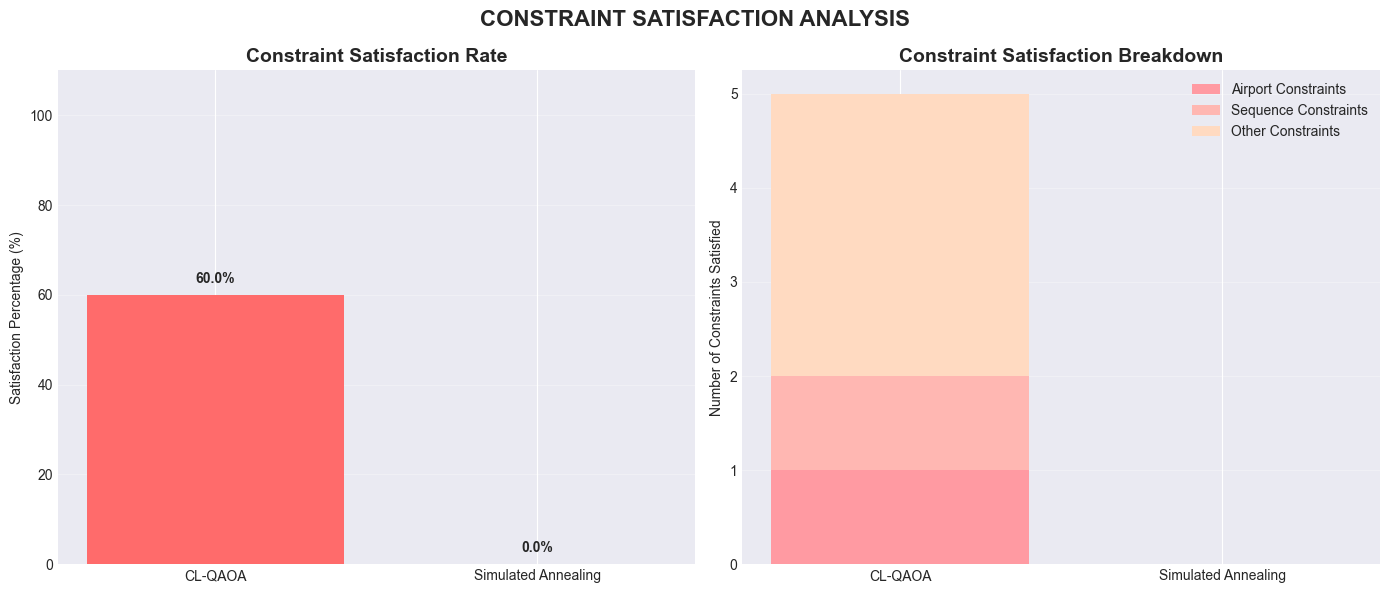

In [29]:
# ============================================
# CELL 8: CONSTRAINT SATISFACTION ANALYSIS
# ============================================

def analyze_constraint_satisfaction(tour, location_names, location_types, node_categories, constraints):
    """Analyze how well the tour satisfies constraints"""
    
    analysis = {
        'total_constraints': 0,
        'satisfied_constraints': 0,
        'violations': [],
        'category_visits': {},
        'sequence_checks': []
    }
    
    # 1. Check node categories
    for i, idx in enumerate(tour):
        category = node_categories[idx]
        if category in analysis['category_visits']:
            analysis['category_visits'][category] += 1
        else:
            analysis['category_visits'][category] = 1
    
    # 2. Check airport constraints (start/end)
    start_node = tour[0]
    end_node = tour[-1]
    start_type = location_types[start_node]
    end_type = location_types[end_node]
    
    analysis['total_constraints'] += 2
    if 'airport' in str(start_type).lower():
        analysis['satisfied_constraints'] += 1
    else:
        analysis['violations'].append(f"Start node ({location_names[start_node]}) is not airport")
    
    if 'airport' in str(end_type).lower():
        analysis['satisfied_constraints'] += 1
    else:
        analysis['violations'].append(f"End node ({location_names[end_node]}) is not airport")
    
    # 3. Check must-visit sequence constraints
    if 'must_visit_sequence' in constraints.get('road_constraints', {}):
        for seq in constraints['road_constraints']['must_visit_sequence']:
            analysis['total_constraints'] += 1
            found_indices = []
            for location in seq:
                for i, idx in enumerate(tour):
                    if location in location_names[idx]:
                        found_indices.append(i)
                        break
            
            if len(found_indices) == len(seq):
                # Check if they're in sequence
                if all(found_indices[i] < found_indices[i+1] for i in range(len(found_indices)-1)):
                    analysis['satisfied_constraints'] += 1
                    analysis['sequence_checks'].append(f"Sequence {seq} satisfied")
                else:
                    analysis['violations'].append(f"Sequence {seq} not in order")
            else:
                analysis['violations'].append(f"Sequence {seq} not fully visited")
    
    # Calculate satisfaction percentage
    if analysis['total_constraints'] > 0:
        analysis['satisfaction_percentage'] = (analysis['satisfied_constraints'] / 
                                              analysis['total_constraints'] * 100)
    else:
        analysis['satisfaction_percentage'] = 100
    
    return analysis

print("="*60)
print("CONSTRAINT SATISFACTION ANALYSIS")
print("="*60)

constraint_analyses = {}
for method, data in methods_results.items():
    print(f"\n{method}:")
    analysis = analyze_constraint_satisfaction(
        data['tour'], 
        location_names, 
        location_types,
        node_categories,
        constraints
    )
    constraint_analyses[method] = analysis
    
    print(f"  Constraints satisfied: {analysis['satisfied_constraints']}/{analysis['total_constraints']}")
    print(f"  Satisfaction: {analysis['satisfaction_percentage']:.1f}%")
    print(f"  Category visits: {analysis['category_visits']}")
    
    if analysis['violations']:
        print(f"  Violations: {len(analysis['violations'])}")
        for violation in analysis['violations'][:3]:  # Show first 3
            print(f"    - {violation}")
        if len(analysis['violations']) > 3:
            print(f"    ... and {len(analysis['violations']) - 3} more")

# Visualize constraint satisfaction
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Bar chart of satisfaction percentages
methods = list(constraint_analyses.keys())
satisfaction = [constraint_analyses[m]['satisfaction_percentage'] for m in methods]

bars = ax1.bar(methods, satisfaction, color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
ax1.set_ylabel('Satisfaction Percentage (%)')
ax1.set_title('Constraint Satisfaction Rate', fontsize=14, fontweight='bold')
ax1.set_ylim(0, 110)
ax1.grid(True, alpha=0.3, axis='y')

for bar, sat in zip(bars, satisfaction):
    ax1.text(bar.get_x() + bar.get_width()/2., sat + 2,
            f'{sat:.1f}%', ha='center', va='bottom', fontweight='bold')

# Pie chart of constraint types
constraint_types = ['Airport Start/End', 'Sequence Order', 'Category Requirements']
satisfied_counts = []
for method in methods:
    analysis = constraint_analyses[method]
    satisfied_counts.append({
        'airport': 1 if analysis['satisfied_constraints'] >= 2 else 0,
        'sequence': analysis['satisfied_constraints'] - 2 if analysis['satisfied_constraints'] > 2 else 0,
        'other': analysis['satisfied_constraints']
    })

# Stacked bar chart
bottom = np.zeros(len(methods))
colors = ['#FF9AA2', '#FFB7B2', '#FFDAC1']
labels = ['Airport Constraints', 'Sequence Constraints', 'Other Constraints']

for i, label in enumerate(labels):
    values = [satisfied_counts[j][['airport', 'sequence', 'other'][i]] for j in range(len(methods))]
    ax2.bar(methods, values, bottom=bottom, label=label, color=colors[i])
    bottom += values

ax2.set_ylabel('Number of Constraints Satisfied')
ax2.set_title('Constraint Satisfaction Breakdown', fontsize=14, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

plt.suptitle('CONSTRAINT SATISFACTION ANALYSIS', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('constraint_satisfaction.png', dpi=300, bbox_inches='tight')
plt.show()

In [31]:
# ============================================
# CELL 9: PERFORMANCE METRICS TABLE
# ============================================

from tabulate import tabulate

print("="*60)
print("COMPREHENSIVE PERFORMANCE METRICS")
print("="*60)

# Prepare table data
table_data = []
for method in methods_results.keys():
    data = methods_results[method]
    analysis = constraint_analyses.get(method, {})
    ar_info = ar_results.get(method, {})
    
    row = [
        method,
        f"{data['actual_cost']:.2f}",
        f"{data['qubo_cost']:.2f}",
        f"{data['runtime']:.2f}s",
        f"{analysis.get('satisfaction_percentage', 0):.1f}%" if analysis else "N/A",
        f"{ar_info.get('AR_min', 'N/A')}" if isinstance(ar_info.get('AR_min'), (int, float)) else "N/A",
        f"{ar_info.get('normalized_to_best', 'N/A')}" if isinstance(ar_info.get('normalized_to_best'), (int, float)) else "N/A",
        len(data['tour'])
    ]
    table_data.append(row)

# Create table
headers = ["Method", "Actual Cost", "QUBO Cost", "Runtime", "Constraint %", "AR_min", "Norm to Best", "Tour Length"]
print(tabulate(table_data, headers=headers, tablefmt="grid", floatfmt=".4f"))

# Calculate summary statistics
print("\n" + "="*60)
print("SUMMARY STATISTICS")
print("="*60)

best_actual = min([data['actual_cost'] for data in methods_results.values()])
worst_actual = max([data['actual_cost'] for data in methods_results.values()])
avg_runtime = np.mean([data['runtime'] for data in methods_results.values()])

print(f"Best Actual Distance: {best_actual:.2f}")
print(f"Worst Actual Distance: {worst_actual:.2f}")
print(f"Range: {worst_actual - best_actual:.2f} ({((worst_actual - best_actual)/worst_actual*100):.1f}% difference)")
print(f"Average Runtime: {avg_runtime:.2f}s")

# Save metrics to CSV
metrics_df = pd.DataFrame(table_data, columns=headers)
metrics_df.to_csv('performance_metrics.csv', index=False)
print(f"\n Metrics saved to 'performance_metrics.csv'")

# Create comparison score
print("\n" + "="*60)
print("OVERALL SCORING (Weighted) - Lower is Better")
print("="*60)

# Normalize metrics
actual_costs = [data['actual_cost'] for data in methods_results.values()]
runtimes = [data['runtime'] for data in methods_results.values()]

norm_costs = [(c - min(actual_costs)) / (max(actual_costs) - min(actual_costs)) 
              if max(actual_costs) > min(actual_costs) else 0 for c in actual_costs]
norm_runtimes = [(r - min(runtimes)) / (max(runtimes) - min(runtimes)) 
                if max(runtimes) > min(runtimes) else 0 for r in runtimes]
satisfaction_scores = [1 - (constraint_analyses[m].get('satisfaction_percentage', 0) / 100) 
                      for m in methods_results.keys()]

# Weighted score (adjust weights as needed)
weights = {'distance': 0.4, 'runtime': 0.3, 'constraints': 0.3}
overall_scores = []

for i, method in enumerate(methods_results.keys()):
    score = (norm_costs[i] * weights['distance'] + 
             norm_runtimes[i] * weights['runtime'] + 
             satisfaction_scores[i] * weights['constraints'])
    overall_scores.append((method, score))

# Sort by score
overall_scores.sort(key=lambda x: x[1])

print("\nRanking (Weighted Score):")
for rank, (method, score) in enumerate(overall_scores, 1):
    print(f"{rank}. {method}: {score:.4f}")

COMPREHENSIVE PERFORMANCE METRICS
+---------------------+---------------+-------------+-----------+----------------+----------+----------------+---------------+
| Method              |   Actual Cost |   QUBO Cost | Runtime   | Constraint %   |   AR_min |   Norm to Best |   Tour Length |
+=====================+===============+=============+===========+================+==========+================+===============+
| CL-QAOA             |        2.2600 |      2.2600 | 218.80s   | 60.0%          |   0.0000 |         1.0000 |           150 |
+---------------------+---------------+-------------+-----------+----------------+----------+----------------+---------------+
| Simulated Annealing |       10.8200 |     10.8200 | 3080.05s  | 0.0%           |   1.0000 |         4.7943 |           150 |
+---------------------+---------------+-------------+-----------+----------------+----------+----------------+---------------+

SUMMARY STATISTICS
Best Actual Distance: 2.26
Worst Actual Distance: 10.82
R